In [1]:
import pandas as pd
import numpy as np
import re
import os

In [2]:
EU_COUNTRIES = [
    'BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 
    'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV',
    'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 
    'PT', 'RO', 'SI', 'SK', 'FI', 'SE'
]

EFTA_COUNTRIES = ['IS', 'LI', 'NO', 'CH']

EU_EFTA = EU_COUNTRIES + EFTA_COUNTRIES

# 2024

## Variables analysis 

### AI adoption rate 

The dependent variable is the proportion of firms within each country - sector using at least one type of AI in 2023. Unit of measurement - share of the firms. PC_ENT

In [3]:
ai_adopt_df = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/ain2.csv', index_col=0)
print(ai_adopt_df)

       freq size_emp nace_r2           indic_is    unit geo  num_2021  \
0         A     GE10       C    E_AIX_CC1SIX_DA  PC_ENT  AT       NaN   
1         A     GE10       C    E_AIX_CC1SIX_DA  PC_ENT  BA       NaN   
2         A     GE10       C    E_AIX_CC1SIX_DA  PC_ENT  BE       NaN   
3         A     GE10       C    E_AIX_CC1SIX_DA  PC_ENT  BG       NaN   
4         A     GE10       C    E_AIX_CC1SIX_DA  PC_ENT  CY       NaN   
...     ...      ...     ...                ...     ...  ..       ...   
221987    A     GE10    S951  E_DI3_VLO_AI_TANY  PC_ENT  RO       NaN   
221988    A     GE10    S951  E_DI3_VLO_AI_TANY  PC_ENT  RS       NaN   
221989    A     GE10    S951  E_DI3_VLO_AI_TANY  PC_ENT  SE       NaN   
221990    A     GE10    S951  E_DI3_VLO_AI_TANY  PC_ENT  SI       NaN   
221991    A     GE10    S951  E_DI3_VLO_AI_TANY  PC_ENT  SK       NaN   

       flag_2021  num_2023 flag_2023  num_2024 flag_2024  
0            NaN      8.24       NaN       NaN       NaN  
1    

In [4]:
un = pd.unique(ai_adopt_df['size_emp'])
print(un)

['GE10']


In [5]:
# Filter the data 
# E_AI_TANY - Enterprises use at least one of the AI technologies

ai_adopt = ai_adopt_df.copy()


ai_adopt = ai_adopt[
    (ai_adopt["indic_is"] == "E_AI_TANY") &
    (ai_adopt["unit"] == "PC_ENT") 
]

ai_adopt = ai_adopt.drop(columns=['indic_is','unit',  'freq', 'size_emp', 'flag_2021','flag_2023','flag_2024'])

ai_adopt = ai_adopt[ai_adopt['geo'].isin(EU_EFTA)]
print(ai_adopt)

       nace_r2 geo  num_2021  num_2023  num_2024
3809         C  AT      9.61     12.31     22.71
3811         C  BE     10.42     15.31     23.24
3812         C  BG      2.88      2.55      4.35
3813         C  CY      2.05      3.81      2.98
3814         C  CZ      4.19      6.01      9.55
...        ...  ..       ...       ...       ...
221156    S951  PT      7.58      8.82     21.94
221157    S951  RO      0.00      0.00      3.08
221159    S951  SE      6.67      6.67       NaN
221160    S951  SI      0.00       NaN     19.22
221161    S951  SK      0.00      0.00      9.09

[1339 rows x 5 columns]


In [6]:
def nace_section_or_nan(s: str) -> str | float:
    s = str(s).strip().upper()
    match = re.fullmatch(r'([A-U])', s)

    if match:
        return match.group(1)
    else:
        return np.nan

ai_adopt['nace_r2_1d'] = ai_adopt['nace_r2'].map(nace_section_or_nan)
print(ai_adopt)

       nace_r2 geo  num_2021  num_2023  num_2024 nace_r2_1d
3809         C  AT      9.61     12.31     22.71          C
3811         C  BE     10.42     15.31     23.24          C
3812         C  BG      2.88      2.55      4.35          C
3813         C  CY      2.05      3.81      2.98          C
3814         C  CZ      4.19      6.01      9.55          C
...        ...  ..       ...       ...       ...        ...
221156    S951  PT      7.58      8.82     21.94        NaN
221157    S951  RO      0.00      0.00      3.08        NaN
221159    S951  SE      6.67      6.67       NaN        NaN
221160    S951  SI      0.00       NaN     19.22        NaN
221161    S951  SK      0.00      0.00      9.09        NaN

[1339 rows x 6 columns]


In [7]:
ai_adopt.drop(columns=['nace_r2'], inplace=True) 
ai_adopt.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)
print(ai_adopt)

       geo  num_2021  num_2023  num_2024 nace_r2
3809    AT      9.61     12.31     22.71       C
3811    BE     10.42     15.31     23.24       C
3812    BG      2.88      2.55      4.35       C
3813    CY      2.05      3.81      2.98       C
3814    CZ      4.19      6.01      9.55       C
...     ..       ...       ...       ...     ...
221156  PT      7.58      8.82     21.94     NaN
221157  RO      0.00      0.00      3.08     NaN
221159  SE      6.67      6.67       NaN     NaN
221160  SI      0.00       NaN     19.22     NaN
221161  SK      0.00      0.00      9.09     NaN

[1339 rows x 5 columns]


In [8]:
ai_adopt = ai_adopt.dropna()
print(ai_adopt)

       geo  num_2021  num_2023  num_2024 nace_r2
3809    AT      9.61     12.31     22.71       C
3811    BE     10.42     15.31     23.24       C
3812    BG      2.88      2.55      4.35       C
3813    CY      2.05      3.81      2.98       C
3814    CZ      4.19      6.01      9.55       C
...     ..       ...       ...       ...     ...
207613  PT     10.81     10.29     12.91       N
207614  RO      3.04      1.57      5.30       N
207616  SE      8.58      8.30     21.63       N
207617  SI      9.02      3.22      7.65       N
207618  SK      8.60     10.16     18.37       N

[238 rows x 5 columns]


In [9]:
ai_adopt = ai_adopt.rename(columns={'num_2021' : 'ai_2021','num_2023' : 'ai_2023', 'num_2024' : 'ai_2024' })
print(ai_adopt)

       geo  ai_2021  ai_2023  ai_2024 nace_r2
3809    AT     9.61    12.31    22.71       C
3811    BE    10.42    15.31    23.24       C
3812    BG     2.88     2.55     4.35       C
3813    CY     2.05     3.81     2.98       C
3814    CZ     4.19     6.01     9.55       C
...     ..      ...      ...      ...     ...
207613  PT    10.81    10.29    12.91       N
207614  RO     3.04     1.57     5.30       N
207616  SE     8.58     8.30    21.63       N
207617  SI     9.02     3.22     7.65       N
207618  SK     8.60    10.16    18.37       N

[238 rows x 5 columns]


In [10]:
print(pd.unique(ai_adopt['nace_r2']))

['C' 'E' 'F' 'G' 'H' 'I' 'J' 'M' 'N']


In [11]:
c = len(pd.unique(ai_adopt['geo']))
print(f'Number of the available countries for the ai adoption variable {c}')

n = len(pd.unique(ai_adopt['nace_r2']))
print(f'Number of the available nace codes for the ai adoption variable {n}')

print(f'Maximum number of the available country-sector rows for the ai adoption variable {c*n}')
print(f'Real number of the available country-sector rows for the ai adoption variable {len(ai_adopt.index)}')


Number of the available countries for the ai adoption variable 28
Number of the available nace codes for the ai adoption variable 9
Maximum number of the available country-sector rows for the ai adoption variable 252
Real number of the available country-sector rows for the ai adoption variable 238


count    238.000000
mean      16.583950
std       14.673848
min        0.000000
25%        6.612500
50%       11.165000
75%       21.630000
max       68.300000
Name: ai_adopt_pc, dtype: float64


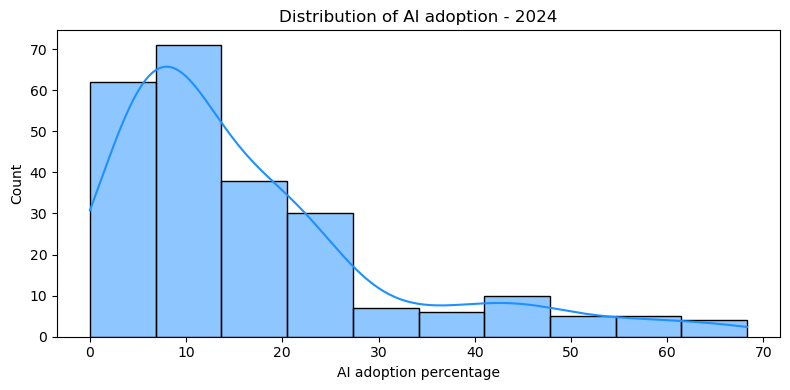

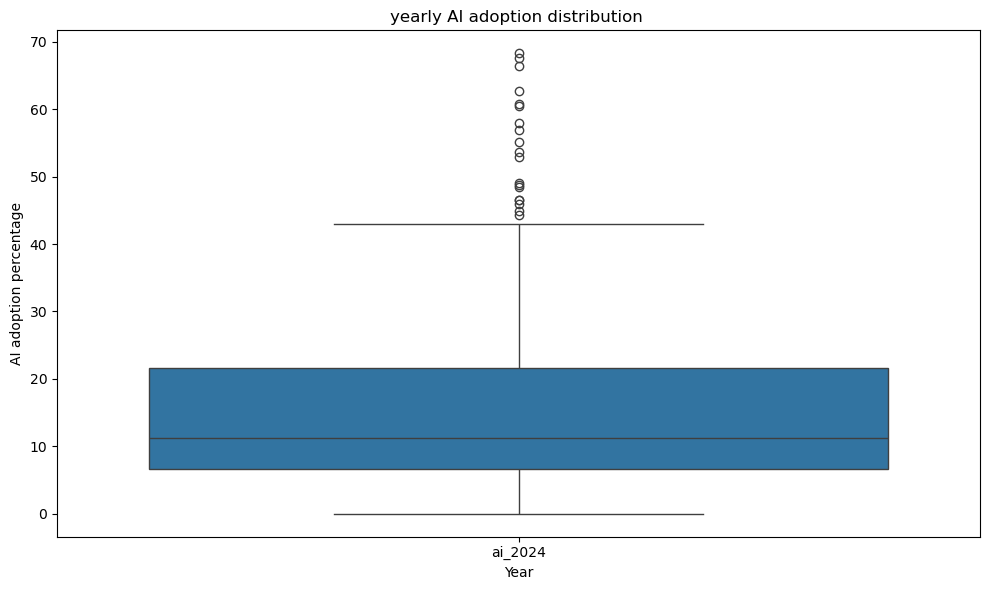

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt to long format for easier plotting and analysis
ai_adopt_long = ai_adopt.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=[ "ai_2024"], #"ai_2021",  "ai_2023",
                  var_name="year",
                  value_name="ai_adopt_pc")

# Descriptive statistics (overall)
desc = ai_adopt_long["ai_adopt_pc"].describe()
print(desc)


# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(ai_adopt_long["ai_adopt_pc"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of AI adoption - 2024")
plt.xlabel("AI adoption percentage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="ai_adopt_pc", data=ai_adopt_long)
plt.title("yearly AI adoption distribution ")
plt.xlabel("Year")
plt.ylabel("AI adoption percentage")
plt.tight_layout()
plt.show()

### Wages

The wage variable measures wages, salaries, bonuses, allowances, employer contributions to saving schemes, and remuneration in kind, as received by workers, in euros per hour. 


In [13]:
wages = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/lc_test.csv')
print(wages)

      freq        unit   lcstruct nace_r2 geo  num_2020 flag_2020  num_2021  \
0        A         EUR        D11       B  AL       NaN       NaN       NaN   
1        A         EUR        D11       B  AT      28.4       NaN      28.8   
2        A         EUR        D11       B  BA       NaN       NaN       NaN   
3        A         EUR        D11       B  BE      31.3       NaN      31.7   
4        A         EUR        D11       B  BG       8.1       NaN       8.8   
...    ...         ...        ...     ...  ..       ...       ...       ...   
11070    A  RT_PRE_NAC  D1_D4_MD5       S  RO       8.4       NaN       4.8   
11071    A  RT_PRE_NAC  D1_D4_MD5       S  RS       6.6       NaN       9.5   
11072    A  RT_PRE_NAC  D1_D4_MD5       S  SE       0.1       NaN       4.0   
11073    A  RT_PRE_NAC  D1_D4_MD5       S  SI       4.1       NaN       3.6   
11074    A  RT_PRE_NAC  D1_D4_MD5       S  SK       4.1       NaN       5.5   

      flag_2021  num_2022 flag_2022  num_2023 flag_

In [14]:
# Filter the data 
# per employee in full-time equivalents, per hour

wg = wages.copy()
wg = wg[
    (wg['unit'] == 'EUR') &
    (wg['lcstruct'] == 'D11') # Wages and Salaries (total)
]

wg = wg.drop(columns=['freq', 'unit', 'lcstruct', 'flag_2020', 'flag_2021', 'flag_2022', 'flag_2023', 'flag_2024'])
wg = wg[wg['geo'].isin(EU_EFTA)]

print(wg)

    nace_r2 geo  num_2020  num_2021  num_2022  num_2023  num_2024
1         B  AT      28.4      28.8      29.2      31.7      34.3
3         B  BE      31.3      31.7      34.0      36.7      37.6
4         B  BG       8.1       8.8      10.3      11.4      12.2
5         B  CH       NaN       NaN       NaN       NaN       NaN
6         B  CY      13.6      14.9      15.0      16.4      17.1
..      ...  ..       ...       ...       ...       ...       ...
885       S  PT      10.2      10.9      10.6      11.5      12.2
886       S  RO       5.4       5.5       6.6       7.2       8.5
888       S  SE      23.5      24.7      23.9      23.3      23.8
889       S  SI      15.0      15.3      15.9      18.2      19.5
890       S  SK       6.8       7.4       7.8       8.6       8.9

[635 rows x 7 columns]


In [15]:
wg['nace_r2_1d'] = wg['nace_r2'].map(nace_section_or_nan)

wg.drop(columns=['nace_r2'], inplace=True) 
wg.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)
print(wg)

    geo  num_2020  num_2021  num_2022  num_2023  num_2024 nace_r2
1    AT      28.4      28.8      29.2      31.7      34.3       B
3    BE      31.3      31.7      34.0      36.7      37.6       B
4    BG       8.1       8.8      10.3      11.4      12.2       B
5    CH       NaN       NaN       NaN       NaN       NaN       B
6    CY      13.6      14.9      15.0      16.4      17.1       B
..   ..       ...       ...       ...       ...       ...     ...
885  PT      10.2      10.9      10.6      11.5      12.2       S
886  RO       5.4       5.5       6.6       7.2       8.5       S
888  SE      23.5      24.7      23.9      23.3      23.8       S
889  SI      15.0      15.3      15.9      18.2      19.5       S
890  SK       6.8       7.4       7.8       8.6       8.9       S

[635 rows x 7 columns]


In [16]:
wg = wg.dropna()
# wg_agg = wg.groupby(['geo', 'nace_r2'])['num_2020'].mean().reset_index()
wg.rename(columns={'num_2020': 'wg_2020', 'num_2021': 'wg_2021', 'num_2022' : 'wg_2022', 'num_2023': 'wg_2023', 'num_2024' : 'wg_2024' }, inplace=True)
print(wg)

    geo  wg_2020  wg_2021  wg_2022  wg_2023  wg_2024 nace_r2
1    AT     28.4     28.8     29.2     31.7     34.3       B
3    BE     31.3     31.7     34.0     36.7     37.6       B
4    BG      8.1      8.8     10.3     11.4     12.2       B
6    CY     13.6     14.9     15.0     16.4     17.1       B
7    CZ     11.2     11.8     13.3     14.9     14.8       B
..   ..      ...      ...      ...      ...      ...     ...
885  PT     10.2     10.9     10.6     11.5     12.2       S
886  RO      5.4      5.5      6.6      7.2      8.5       S
888  SE     23.5     24.7     23.9     23.3     23.8       S
889  SI     15.0     15.3     15.9     18.2     19.5       S
890  SK      6.8      7.4      7.8      8.6      8.9       S

[441 rows x 7 columns]


count    441.000000
mean      24.514966
std       13.642587
min        6.300000
25%       13.000000
50%       20.900000
75%       32.300000
max       82.800000
Name: wage_eur_hr, dtype: float64


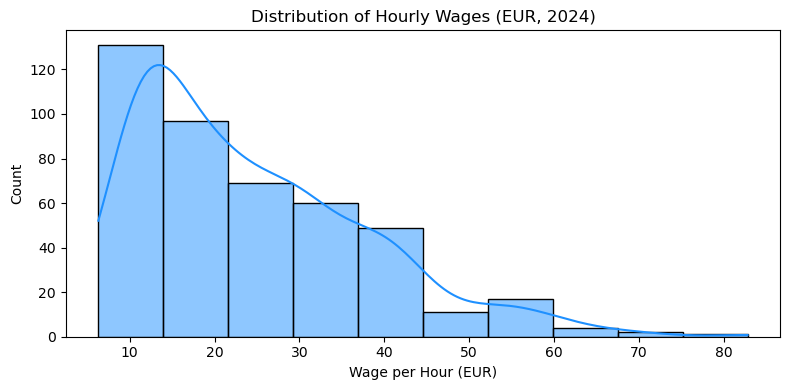

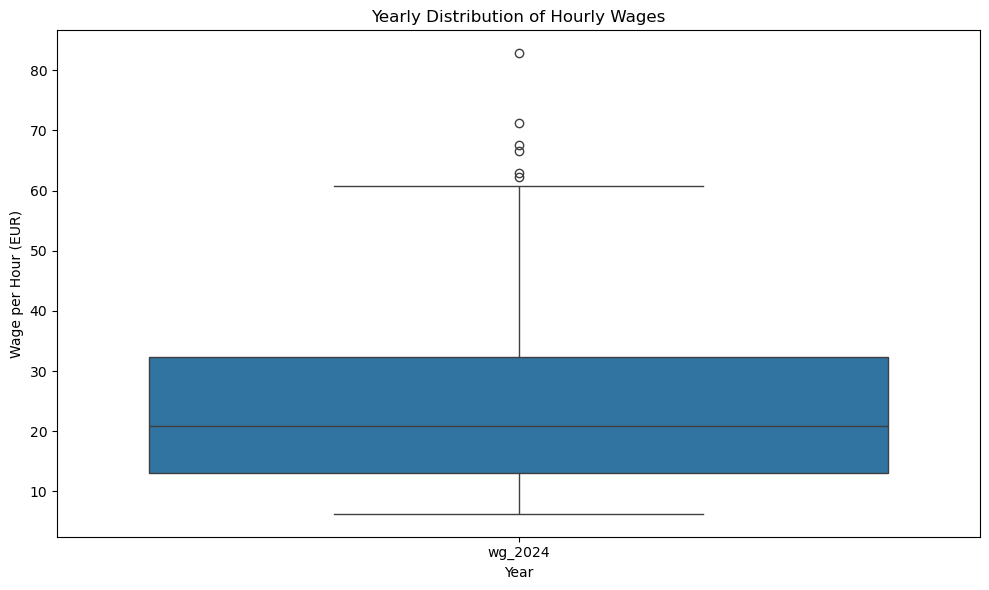

In [17]:
df = wg.copy()

df_long = df.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=["wg_2024"], # "wg_2020", "wg_2021", "wg_2022", "wg_2023",
                  var_name="year",
                  value_name="wage_eur_hr")

# Descriptive statistics (overall)
desc = df_long["wage_eur_hr"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["wage_eur_hr"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Hourly Wages (EUR, 2024)")
plt.xlabel("Wage per Hour (EUR)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="wage_eur_hr", data=df_long)
plt.title("Yearly Distribution of Hourly Wages")
plt.xlabel("Year")
plt.ylabel("Wage per Hour (EUR)")
plt.tight_layout()
plt.show()

In [18]:
print(pd.unique(wg['nace_r2']))

['B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'M' 'N' 'P' 'Q' 'R' 'S']


In [19]:
print('WAGES')
c_1 = len(pd.unique(wg['geo']))
print(f'Number of the available countries for the wages in 2016 variable {c_1}')

n_1 = len(pd.unique(wg['nace_r2']))
print(f'Number of the available nace codes for the wages in 2016 variable {n_1}')

print(f'Maximum number of the available country-sector rows for the wages in 2016 variable {c_1*n_1}')
print(f'Real number of the available country-sector rows for the wages in 2016 variable {len(wg.index)}')

WAGES
Number of the available countries for the wages in 2016 variable 29
Number of the available nace codes for the wages in 2016 variable 16
Maximum number of the available country-sector rows for the wages in 2016 variable 464
Real number of the available country-sector rows for the wages in 2016 variable 441


### Enterprises that provided training to develop/upgrade ICT skills

In [20]:
train = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/train.csv')
print(train)

      freq size_emp nace_r2       indic_is         unit geo  num_2020  \
0        A     GE10       C  E_ITSP2X_ITT2       PC_ENT  AT      3.96   
1        A     GE10       C  E_ITSP2X_ITT2       PC_ENT  BA      2.90   
2        A     GE10       C  E_ITSP2X_ITT2       PC_ENT  BE       NaN   
3        A     GE10       C  E_ITSP2X_ITT2       PC_ENT  BG       NaN   
4        A     GE10       C  E_ITSP2X_ITT2       PC_ENT  CY     11.28   
...    ...      ...     ...            ...          ...  ..       ...   
16549    A     GE10    S951       E_ITUST2  PC_ENT_CUSE  SE       NaN   
16550    A     GE10    S951       E_ITUST2  PC_ENT_CUSE  SI       NaN   
16551    A     GE10    S951       E_ITUST2  PC_ENT_CUSE  SK       NaN   
16552    A     GE10    S951       E_ITUST2  PC_ENT_CUSE  TR       NaN   
16553    A     GE10    S951       E_ITUST2  PC_ENT_CUSE  UK       NaN   

      flag_2020  num_2022 flag_2022  num_2024 flag_2024  
0           NaN      5.50       NaN      5.18       NaN  
1      

In [21]:
# Filter the data 

tr = train.copy()
tr = tr[
    (tr['indic_is'] == 'E_ITT2') & # Enterprise provided training to their personnel to develop their ICT skills
    (tr['unit'] == 'PC_ENT') # Percentage of enterprises 
]

tr = tr.drop(columns=['freq', 'size_emp', 'indic_is', 'unit', 'flag_2020', 'flag_2022', 'flag_2024'])
tr = tr[tr['geo'].isin(EU_EFTA)]

print(tr)

      nace_r2 geo  num_2020  num_2022  num_2024
239         C  AT     20.37     25.60     26.06
241         C  BE       NaN     33.89     40.12
242         C  BG      5.38      6.47      5.82
243         C  CY     19.69     20.51     17.41
244         C  CZ     27.60     23.76     28.35
...       ...  ..       ...       ...       ...
16425    S951  PT     63.29       NaN       NaN
16426    S951  RO     21.78     24.08     14.51
16428    S951  SE       NaN     53.33       NaN
16429    S951  SI       NaN       NaN     76.96
16430    S951  SK     18.33     23.08     18.18

[1403 rows x 5 columns]


In [22]:
tr['nace_r2_1d'] = tr['nace_r2'].map(nace_section_or_nan)

tr.drop(columns=['nace_r2'], inplace=True) 
tr.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)
print(tr)

      geo  num_2020  num_2022  num_2024 nace_r2
239    AT     20.37     25.60     26.06       C
241    BE       NaN     33.89     40.12       C
242    BG      5.38      6.47      5.82       C
243    CY     19.69     20.51     17.41       C
244    CZ     27.60     23.76     28.35       C
...    ..       ...       ...       ...     ...
16425  PT     63.29       NaN       NaN     NaN
16426  RO     21.78     24.08     14.51     NaN
16428  SE       NaN     53.33       NaN     NaN
16429  SI       NaN       NaN     76.96     NaN
16430  SK     18.33     23.08     18.18     NaN

[1403 rows x 5 columns]


In [23]:
tr = tr.dropna()
tr.rename(columns={'num_2020': 'tr_2020', 'num_2022' : 'tr_2022', 'num_2024' : 'tr_2024' }, inplace=True)
print(tr)

      geo  tr_2020  tr_2022  tr_2024 nace_r2
239    AT    20.37    25.60    26.06       C
242    BG     5.38     6.47     5.82       C
243    CY    19.69    20.51    17.41       C
244    CZ    27.60    23.76    28.35       C
245    DE    26.58    27.82    28.73       C
...    ..      ...      ...      ...     ...
15233  PT    32.41    27.20    32.82       N
15234  RO     4.19     9.80    15.37       N
15236  SE    27.38    25.01    25.74       N
15237  SI    17.44    27.52    22.73       N
15238  SK    14.74     7.67    17.50       N

[182 rows x 5 columns]


count    182.000000
mean      24.829505
std       18.311179
min        2.090000
25%       12.587500
50%       19.180000
75%       28.980000
max       84.700000
Name: tr_ent_pc, dtype: float64


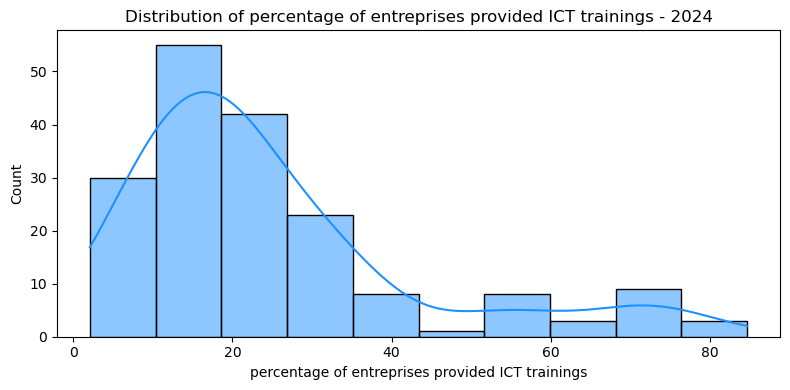

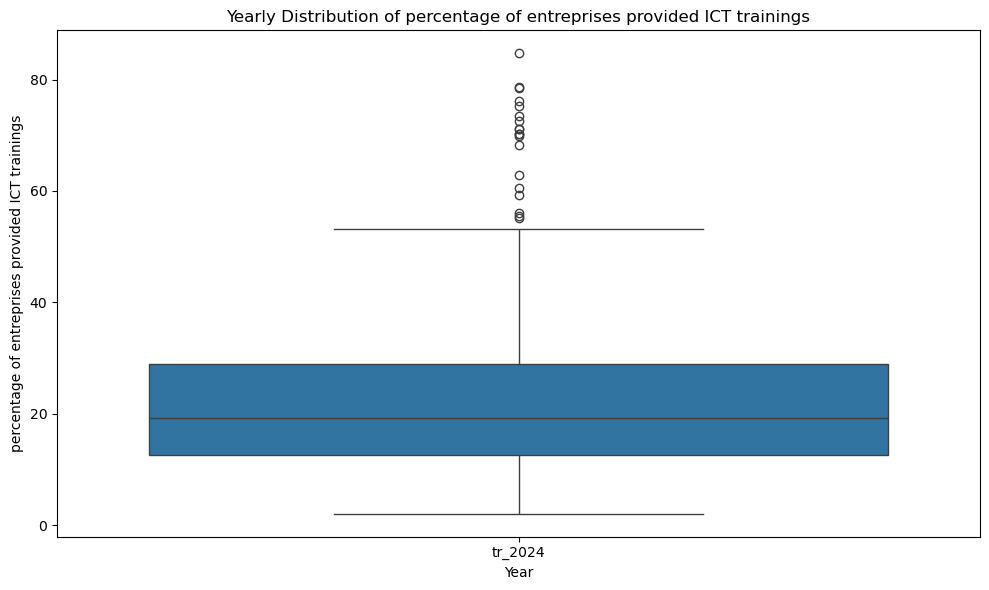

In [24]:
df = tr.copy()

df_long = df.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=["tr_2024"], # "tr_2020",  "tr_2022",
                  var_name="year",
                  value_name="tr_ent_pc")

# Descriptive statistics (overall)
desc = df_long["tr_ent_pc"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["tr_ent_pc"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of percentage of entreprises provided ICT trainings - 2024")
plt.xlabel("percentage of entreprises provided ICT trainings")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="tr_ent_pc", data=df_long)
plt.title("Yearly Distribution of percentage of entreprises provided ICT trainings")
plt.xlabel("Year")
plt.ylabel("percentage of entreprises provided ICT trainings")
plt.tight_layout()
plt.show()

In [25]:
print(pd.unique(tr['nace_r2']))

['C' 'F' 'G' 'H' 'I' 'J' 'N']


In [26]:
print('TRAINING')
c_1 = len(pd.unique(tr['geo']))
print(f'Number of the available countries for the wages in 2016 variable {c_1}')

n_1 = len(pd.unique(tr['nace_r2']))
print(f'Number of the available nace codes for the wages in 2016 variable {n_1}')

print(f'Maximum number of the available country-sector rows for the wages in 2016 variable {c_1*n_1}')
print(f'Real number of the available country-sector rows for the wages in 2016 variable {len(tr.index)}')

TRAINING
Number of the available countries for the wages in 2016 variable 27
Number of the available nace codes for the wages in 2016 variable 7
Maximum number of the available country-sector rows for the wages in 2016 variable 189
Real number of the available country-sector rows for the wages in 2016 variable 182


### Enterprises that employ ICT specialists

In [27]:
ict_emp = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/ict_spec.csv')
print(ict_emp)

     freq size_emp nace_r2 indic_is         unit geo  num_2020 flag_2020  \
0       A     GE10       C  E_ITSP2       PC_ENT  AL       NaN       NaN   
1       A     GE10       C  E_ITSP2       PC_ENT  AT     28.74       NaN   
2       A     GE10       C  E_ITSP2       PC_ENT  BA     12.92       NaN   
3       A     GE10       C  E_ITSP2       PC_ENT  BE       NaN         u   
4       A     GE10       C  E_ITSP2       PC_ENT  BG     15.16       NaN   
...   ...      ...     ...      ...          ...  ..       ...       ...   
3338    A     GE10    S951  E_ITSP2  PC_ENT_CUSE  SE       NaN       NaN   
3339    A     GE10    S951  E_ITSP2  PC_ENT_CUSE  SI       NaN       NaN   
3340    A     GE10    S951  E_ITSP2  PC_ENT_CUSE  SK       NaN       NaN   
3341    A     GE10    S951  E_ITSP2  PC_ENT_CUSE  TR       NaN       NaN   
3342    A     GE10    S951  E_ITSP2  PC_ENT_CUSE  UK       NaN       NaN   

      num_2022 flag_2022  num_2024 flag_2024  
0        11.22         b       NaN      

In [28]:
# Filter the data 
# E_ITSP2 - Enterprise employed ICT/IT specialists (reduced comparability with 2007)

ict_emp = ict_emp.copy()
ict_emp = ict_emp[
    (ict_emp['unit'] == 'PC_ENT') # Percentage of enterprises 
]

ict_emp = ict_emp.drop(columns=['freq', 'size_emp', 'indic_is', 'unit', 'flag_2020', 'flag_2022', 'flag_2024'])
ict_emp = ict_emp[ict_emp['geo'].isin(EU_EFTA)]

print(ict_emp)

     nace_r2 geo  num_2020  num_2022  num_2024
1          C  AT     28.74     28.37     30.02
3          C  BE       NaN     35.46     35.31
4          C  BG     15.16     14.73     15.53
5          C  CY     14.23     16.29     14.93
6          C  CZ     21.66     21.42     23.05
...      ...  ..       ...       ...       ...
3295    S951  PT     83.79       NaN       NaN
3296    S951  RO     42.24     33.20     31.65
3298    S951  SE       NaN     33.33       NaN
3299    S951  SI       NaN       NaN    100.00
3300    S951  SK     26.67     23.08     68.18

[1403 rows x 5 columns]


In [29]:
ict_emp['nace_r2_1d'] = ict_emp['nace_r2'].map(nace_section_or_nan)

ict_emp.drop(columns=['nace_r2'], inplace=True) 
ict_emp.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)
print(ict_emp)

     geo  num_2020  num_2022  num_2024 nace_r2
1     AT     28.74     28.37     30.02       C
3     BE       NaN     35.46     35.31       C
4     BG     15.16     14.73     15.53       C
5     CY     14.23     16.29     14.93       C
6     CZ     21.66     21.42     23.05       C
...   ..       ...       ...       ...     ...
3295  PT     83.79       NaN       NaN     NaN
3296  RO     42.24     33.20     31.65     NaN
3298  SE       NaN     33.33       NaN     NaN
3299  SI       NaN       NaN    100.00     NaN
3300  SK     26.67     23.08     68.18     NaN

[1403 rows x 5 columns]


In [30]:
ict_emp = ict_emp.dropna()
ict_emp.rename(columns={'num_2020': 'spec_2020', 'num_2022' : 'spec_2022', 'num_2024' : 'spec_2024' }, inplace=True)
print(ict_emp)

     geo  spec_2020  spec_2022  spec_2024 nace_r2
1     AT      28.74      28.37      30.02       C
4     BG      15.16      14.73      15.53       C
5     CY      14.23      16.29      14.93       C
6     CZ      21.66      21.42      23.05       C
7     DE      24.97      25.82      26.81       C
...   ..        ...        ...        ...     ...
3054  PT      29.51      29.67      29.37       N
3055  RO      14.31      11.35      15.56       N
3057  SE      17.58      17.64      11.41       N
3058  SI      10.39      14.76      13.80       N
3059  SK      16.90      13.37      13.68       N

[187 rows x 5 columns]


count    187.000000
mean      25.820963
std       23.853687
min        1.580000
25%       11.020000
50%       17.110000
75%       28.140000
max       98.250000
Name: empl_spec_enterp_pc, dtype: float64


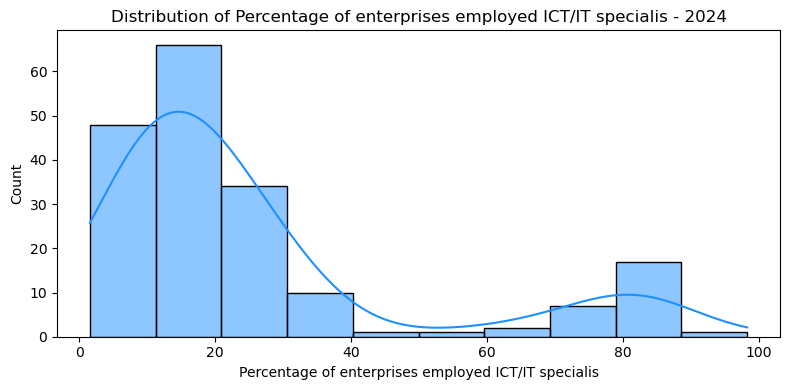

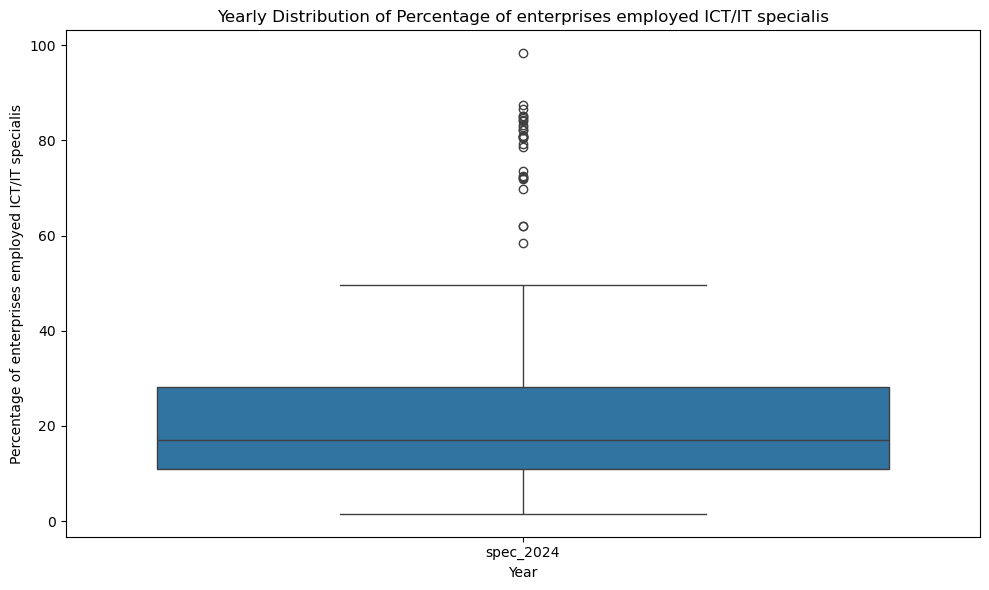

In [31]:
df = ict_emp

df_long = df.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=["spec_2024"], # "spec_2020", "spec_2022", 
                  var_name="year",
                  value_name="empl_spec_enterp_pc")

# Descriptive statistics (overall)
desc = df_long["empl_spec_enterp_pc"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["empl_spec_enterp_pc"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Percentage of enterprises employed ICT/IT specialis - 2024")
plt.xlabel("Percentage of enterprises employed ICT/IT specialis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="empl_spec_enterp_pc", data=df_long)
plt.title("Yearly Distribution of Percentage of enterprises employed ICT/IT specialis")
plt.xlabel("Year")
plt.ylabel("Percentage of enterprises employed ICT/IT specialis")
plt.tight_layout()
plt.show()

In [32]:
print(pd.unique(ict_emp['nace_r2']))

['C' 'F' 'G' 'H' 'I' 'J' 'N']


In [33]:
print('EMPLOYED ICT SPECIALISTS')
c_1 = len(pd.unique(ict_emp['geo']))
print(f'Number of the available countries for the wages in 2016 variable {c_1}')

n_1 = len(pd.unique(ict_emp['nace_r2']))
print(f'Number of the available nace codes for the wages in 2016 variable {n_1}')

print(f'Maximum number of the available country-sector rows for the wages in 2016 variable {c_1*n_1}')
print(f'Real number of the available country-sector rows for the wages in 2016 variable {len(ict_emp.index)}')

EMPLOYED ICT SPECIALISTS
Number of the available countries for the wages in 2016 variable 28
Number of the available nace codes for the wages in 2016 variable 7
Maximum number of the available country-sector rows for the wages in 2016 variable 196
Real number of the available country-sector rows for the wages in 2016 variable 187


### Additional variables. Education

In [34]:
educ = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/educ.csv')
print(educ)

       freq unit nace_r2 isced11     age sex geo  num_2020 flag_2020  \
0         A   PC       A   ED0-2  Y15-24   F  AT       NaN         u   
1         A   PC       A   ED0-2  Y15-24   F  BA       NaN       NaN   
2         A   PC       A   ED0-2  Y15-24   F  BE       NaN         u   
3         A   PC       A   ED0-2  Y15-24   F  BG       NaN         u   
4         A   PC       A   ED0-2  Y15-24   F  CH       NaN         u   
...     ...  ...     ...     ...     ...  ..  ..       ...       ...   
241725    A   PC       U   ED5-8  Y55-74   T  SE       NaN         u   
241726    A   PC       U   ED5-8  Y55-74   T  SI       NaN       NaN   
241727    A   PC       U   ED5-8  Y55-74   T  SK       NaN       NaN   
241728    A   PC       U   ED5-8  Y55-74   T  TR       NaN         u   
241729    A   PC       U   ED5-8  Y55-74   T  UK       NaN       NaN   

        num_2021 flag_2021  num_2022 flag_2022  num_2023 flag_2023  num_2024  \
0            NaN        bu       NaN         u       Na

In [35]:
# Filter the data 
# unit - PC, percent

educ = educ.copy()
educ = educ[
    (educ['sex'] == 'T')& # for all genders
    (educ['age'] == 'Y18-69')& 
    (educ['isced11'] == 'ED5-8')   # 5-8: Tertiary education (levels 5-8)
]

educ = educ.drop(columns=['freq', 'unit', 'age', 'sex', 'flag_2020', 'flag_2021', 'flag_2022', 'flag_2023', 'flag_2024'])
educ = educ[educ['geo'].isin(EU_EFTA)]

print(educ)

       nace_r2 isced11 geo  num_2020  num_2021  num_2022  num_2023  num_2024
9664         A   ED5-8  AT      30.4      22.2      24.4      22.6      33.8
9666         A   ED5-8  BE      19.8      28.7      36.2      36.0      41.1
9667         A   ED5-8  BG       8.1       7.5       6.7       8.6      12.7
9668         A   ED5-8  CH      21.7      23.4      22.9      23.9      29.5
9669         A   ED5-8  CY      15.9      21.5      21.4      18.9      17.3
...        ...     ...  ..       ...       ...       ...       ...       ...
240728       U   ED5-8  PT       NaN       NaN       NaN       NaN       NaN
240729       U   ED5-8  RO       NaN       NaN       NaN       NaN       NaN
240731       U   ED5-8  SE       NaN       NaN       NaN       NaN       NaN
240732       U   ED5-8  SI       NaN       NaN       NaN       NaN       NaN
240733       U   ED5-8  SK       NaN       NaN       NaN       NaN       NaN

[681 rows x 8 columns]


In [36]:
educ['nace_r2_1d'] = educ['nace_r2'].map(nace_section_or_nan)

educ.drop(columns=['nace_r2'], inplace=True) 
educ.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)
print(educ)

       isced11 geo  num_2020  num_2021  num_2022  num_2023  num_2024 nace_r2
9664     ED5-8  AT      30.4      22.2      24.4      22.6      33.8       A
9666     ED5-8  BE      19.8      28.7      36.2      36.0      41.1       A
9667     ED5-8  BG       8.1       7.5       6.7       8.6      12.7       A
9668     ED5-8  CH      21.7      23.4      22.9      23.9      29.5       A
9669     ED5-8  CY      15.9      21.5      21.4      18.9      17.3       A
...        ...  ..       ...       ...       ...       ...       ...     ...
240728   ED5-8  PT       NaN       NaN       NaN       NaN       NaN       U
240729   ED5-8  RO       NaN       NaN       NaN       NaN       NaN       U
240731   ED5-8  SE       NaN       NaN       NaN       NaN       NaN       U
240732   ED5-8  SI       NaN       NaN       NaN       NaN       NaN       U
240733   ED5-8  SK       NaN       NaN       NaN       NaN       NaN       U

[681 rows x 8 columns]


In [37]:
educ = educ.dropna()
educ.rename(columns={'num_2020': 'educ_2020', 'num_2021' : 'educ_2021', 'num_2022' : 'educ_2022', 'num_2023' : 'educ_2023','num_2024' : 'educ_2024' }, inplace=True)
print(educ)

       isced11 geo  educ_2020  educ_2021  educ_2022  educ_2023  educ_2024  \
9664     ED5-8  AT       30.4       22.2       24.4       22.6       33.8   
9666     ED5-8  BE       19.8       28.7       36.2       36.0       41.1   
9667     ED5-8  BG        8.1        7.5        6.7        8.6       12.7   
9668     ED5-8  CH       21.7       23.4       22.9       23.9       29.5   
9669     ED5-8  CY       15.9       21.5       21.4       18.9       17.3   
...        ...  ..        ...        ...        ...        ...        ...   
240702   ED5-8  CH       81.3       75.4       70.1       75.9       81.2   
240703   ED5-8  CY       53.0       50.5       48.0       63.4       56.1   
240713   ED5-8  FR       79.7       77.9       79.5       75.4       75.5   
240718   ED5-8  IT       52.1       60.9       60.8       63.6       64.3   
240720   ED5-8  LU       89.4       90.1       94.0       94.1       93.6   

       nace_r2  
9664         A  
9666         A  
9667         A  
9668   

count    536.000000
mean      42.980784
std       22.085808
min        3.600000
25%       23.775000
50%       39.550000
75%       61.725000
max       93.600000
Name: high_educ_pc, dtype: float64


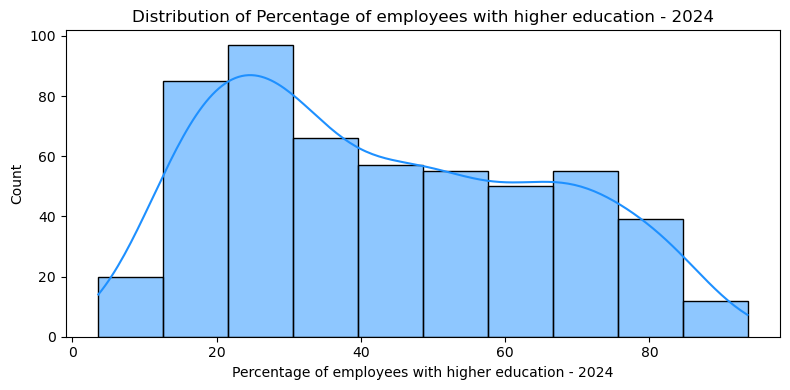

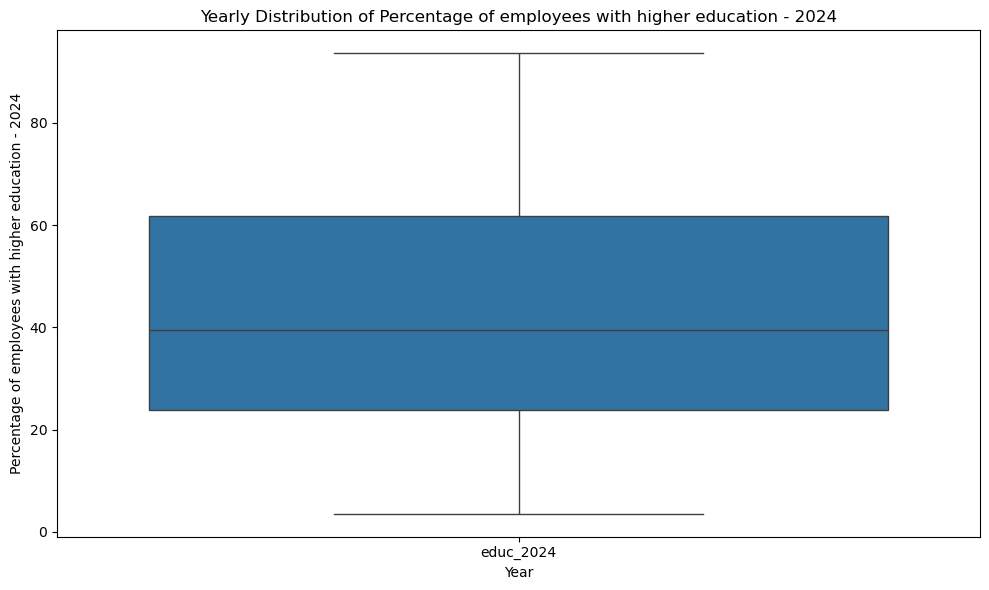

In [38]:
df = educ

df_long = df.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=["educ_2024"],
                  var_name="year",
                  value_name="high_educ_pc")

# Descriptive statistics (overall)
desc = df_long["high_educ_pc"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["high_educ_pc"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Percentage of employees with higher education - 2024")
plt.xlabel("Percentage of employees with higher education - 2024")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="high_educ_pc", data=df_long)
plt.title("Yearly Distribution of Percentage of employees with higher education - 2024")
plt.xlabel("Year")
plt.ylabel("Percentage of employees with higher education - 2024")
plt.tight_layout()
plt.show()

### Occupation

In [39]:
occup = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/occup.csv')

# Filter 
# unit - Ths_per, thousandpersons
occup = occup.copy()
occup = occup[
    (occup['sex'] == 'T')& # for all genders
    (occup['age'] == 'Y20-64') # From 20 to 64 years
]

occup = occup.drop(columns=['freq', 'unit', 'age', 'sex', 'flag_2020', 'flag_2021', 'flag_2022', 'flag_2023', 'flag_2024'])
occup = occup[occup['geo'].isin(EU_EFTA)]
print(occup)

      nace_r2 isco08 geo  num_2020  num_2021  num_2022  num_2023  num_2024
18030       A    NRP  CH       NaN       1.6       2.1       1.4       1.7
18031       A    NRP  DE       NaN       NaN       NaN       NaN       NaN
18032       A    NRP  DK       NaN       NaN       NaN       NaN       NaN
18035       A    NRP  FI       NaN       NaN       NaN       NaN       NaN
18036       A    NRP  FR       NaN       6.2       NaN       NaN       NaN
...       ...    ...  ..       ...       ...       ...       ...       ...
27360       U  TOTAL  PT       NaN       NaN       NaN       NaN       NaN
27361       U  TOTAL  RO       NaN       NaN       NaN       NaN       NaN
27363       U  TOTAL  SE       NaN       NaN       NaN       NaN       NaN
27364       U  TOTAL  SI       NaN       NaN       NaN       NaN       NaN
27365       U  TOTAL  SK       NaN       NaN       NaN       NaN       NaN

[7370 rows x 8 columns]


In [40]:
occup['nace_r2_1d'] = occup['nace_r2'].map(nace_section_or_nan)

occup.drop(columns=['nace_r2'], inplace=True) 
occup.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)
# print(occup)

occup = occup.dropna()
occup.rename(columns={'num_2020': 'occup_2020', 'num_2021' : 'occup_2021', 'num_2022' : 'occup_2022', 'num_2023' : 'occup_2023','num_2024' : 'occup_2024' }, inplace=True)
print(occup)

      isco08 geo  occup_2020  occup_2021  occup_2022  occup_2023  occup_2024  \
18076    OC1  CZ         3.2         4.1         4.6         5.0         4.6   
18082    OC1  ES        14.4        13.2        16.5        17.3        17.1   
18085    OC1  FR        17.9        26.0        31.8        32.5        28.4   
18086    OC1  HR         2.1         1.9         2.0         2.7         3.0   
18087    OC1  HU         5.7         5.9         7.2         6.6         7.1   
...      ...  ..         ...         ...         ...         ...         ...   
27338  TOTAL  DK         2.7         2.7         2.9         3.3         2.2   
27342  TOTAL  ES         4.5         4.1         3.4         4.1         5.9   
27345  TOTAL  FR        20.1        16.3        14.5        18.4        19.9   
27350  TOTAL  IT        16.4        15.7        18.1        16.6        16.4   
27352  TOTAL  LU        16.2        19.0        20.0        21.2        26.0   

      nace_r2  
18076       A  
18082  

In [41]:
# -- Calculate share_high_skill -- 
# Select the relevant occupation groups
high_skill_codes = ['OC1', 'OC2', 'OC3']
total_code = 'TOTAL'
relevant_codes = high_skill_codes + [total_code]

occup_filtered = occup[occup['isco08'].isin(relevant_codes)].copy()
occup_filtered.rename(columns={'occup_2024': 'value'}, inplace=True)

In [42]:
occup_pivoted = occup_filtered.pivot_table(
    index=['geo', 'nace_r2'], # The unique identifiers for your merged dataset
    columns='isco08',
    values='value',
    aggfunc='sum' # Use sum in case there were multiple entries per year/code (though unlikely after your initial filtering)
).reset_index()

# Rename the columns for clarity
occup_pivoted.rename(columns={
    'OC1': 'OC1_Managers',
    'OC2': 'OC2_Professionals',
    'OC3': 'OC3_Technicians',
    'TOTAL': 'TOTAL_Occupied'
}, inplace=True)

print(occup_pivoted)

isco08 geo nace_r2  OC1_Managers  OC2_Professionals  OC3_Technicians  \
0       AT       A           NaN                NaN              5.0   
1       AT       B           NaN                NaN              NaN   
2       AT       C          48.5               86.9            136.7   
3       AT       D           NaN                6.6              7.4   
4       AT       E           NaN                NaN              4.2   
..      ..     ...           ...                ...              ...   
583     SK       O           9.7               35.4             49.6   
584     SK       P           8.2              148.8              NaN   
585     SK       Q           NaN               43.4             71.9   
586     SK       R           NaN                7.1              8.0   
587     SK       S           NaN                NaN              NaN   

isco08  TOTAL_Occupied  
0                109.5  
1                  7.9  
2                678.1  
3                 27.9  
4         

In [43]:
# Calculate the share_high_skill variable
occup_pivoted['total_high_skill'] = (
    occup_pivoted['OC1_Managers'] + 
    occup_pivoted['OC2_Professionals'] + 
    occup_pivoted['OC3_Technicians']
)

# Calculate the share (as a percentage)
occup_pivoted['share_high_skill'] = (
    occup_pivoted['total_high_skill'] / occup_pivoted['TOTAL_Occupied']
) * 100 # Multiply by 100 to get a percentage (0-100)

# Keep only the essential columns for  merging. Please note that the year 2024 was used only. 
share_high_skill_df = occup_pivoted[['geo', 'nace_r2', 'share_high_skill']].copy()

share_high_skill_df = share_high_skill_df.dropna()
print(share_high_skill_df)

isco08 geo nace_r2  share_high_skill
2       AT       C         40.126825
5       AT       F         29.300743
6       AT       G         26.423257
7       AT       H         23.230844
9       AT       J         89.534884
..      ..     ...               ...
571     SK       C         25.630178
574     SK       F         24.281884
575     SK       G         23.282083
578     SK       J         85.416667
583     SK       O         45.138227

[348 rows x 3 columns]


count    348.000000
mean      51.967960
std       26.215417
min        3.001185
25%       27.344246
50%       50.297235
75%       76.656095
max       96.432178
Name: share_high_skill_pc, dtype: float64


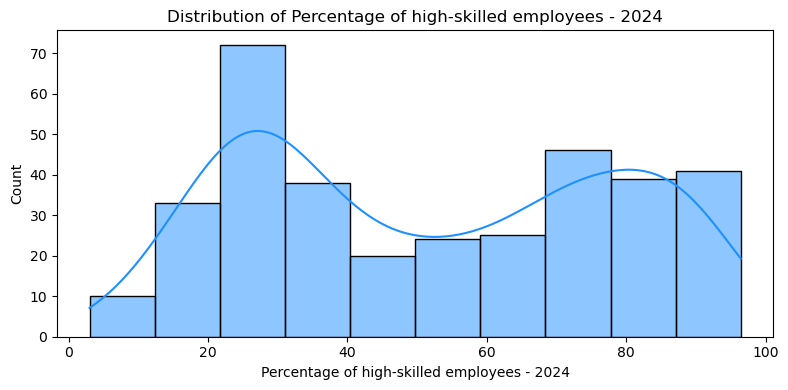

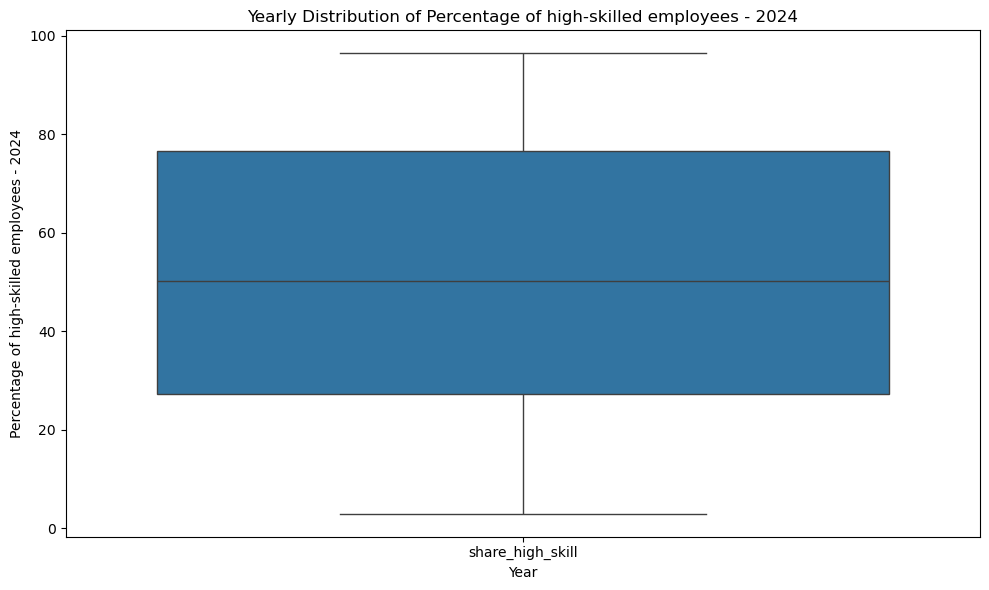

In [44]:
df = share_high_skill_df

df_long = df.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=["share_high_skill"],
                  var_name="year",
                  value_name="share_high_skill_pc")

# Descriptive statistics (overall)
desc = df_long["share_high_skill_pc"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["share_high_skill_pc"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Percentage of high-skilled employees - 2024")
plt.xlabel("Percentage of high-skilled employees - 2024")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="share_high_skill_pc", data=df_long)
plt.title("Yearly Distribution of Percentage of high-skilled employees - 2024")
plt.xlabel("Year")
plt.ylabel("Percentage of high-skilled employees - 2024")
plt.tight_layout()
plt.show()

### Unemployment rate 


In [45]:
unempl_r = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/unempl_r.csv')

# Filter 
# Y15-74 default age class
# sex total is default


unempl_r = unempl_r.copy()
unempl_r = unempl_r[ 
    (unempl_r['unit'] == 'PC_ACT') # Percentage of population in the labour force
]

unempl_r = unempl_r.drop(columns=['freq', 'unit', 'age', 'sex', 'flag_2020', 'flag_2021', 'flag_2022', 'flag_2023', 'flag_2024'])
unempl_r = unempl_r[unempl_r['geo'].isin(EU_EFTA)]
print(unempl_r)

   geo  num_2020  num_2021  num_2022  num_2023  num_2024
0   AT       6.0       6.2       4.8       5.1       5.2
2   BE       5.8       6.3       5.6       5.5       5.7
3   BG       6.1       5.2       4.2       4.3       4.2
4   CH       4.8       5.1       4.1       4.1       4.4
5   CY       7.6       7.2       6.3       5.8       4.9
6   CZ       2.6       2.8       2.2       2.6       2.6
7   DE       3.6       3.6       3.1       3.1       3.4
8   DK       5.6       5.1       4.5       5.1       6.2
10  EE       6.9       6.2       5.6       6.4       7.6
11  EL      17.6      14.7      12.5      11.1      10.1
12  ES      15.5      14.9      13.0      12.2      11.4
14  FI       7.7       7.7       6.8       7.2       8.4
15  FR       8.0       7.9       7.3       7.3       7.4
16  HR       7.4       7.5       6.8       6.1       5.0
17  HU       4.1       4.0       3.6       4.1       4.5
18  IE       5.9       6.2       4.5       4.3       4.3
19  IS       5.5       6.1     

In [46]:
unempl_r = unempl_r.dropna()
unempl_r.rename(columns={'num_2020': 'unempl_r_2020', 'num_2021' : 'unempl_r_2021', 'num_2022' : 'unempl_r_2022', 'num_2023' : 'unempl_r_2023','num_2024' : 'unempl_r_2024' }, inplace=True)
print(unempl_r)

   geo  unempl_r_2020  unempl_r_2021  unempl_r_2022  unempl_r_2023  \
0   AT            6.0            6.2            4.8            5.1   
2   BE            5.8            6.3            5.6            5.5   
3   BG            6.1            5.2            4.2            4.3   
4   CH            4.8            5.1            4.1            4.1   
5   CY            7.6            7.2            6.3            5.8   
6   CZ            2.6            2.8            2.2            2.6   
7   DE            3.6            3.6            3.1            3.1   
8   DK            5.6            5.1            4.5            5.1   
10  EE            6.9            6.2            5.6            6.4   
11  EL           17.6           14.7           12.5           11.1   
12  ES           15.5           14.9           13.0           12.2   
14  FI            7.7            7.7            6.8            7.2   
15  FR            8.0            7.9            7.3            7.3   
16  HR            7.

count    30.000000
mean      5.626667
std       2.133143
min       2.600000
25%       4.050000
50%       5.250000
75%       6.800000
max      11.400000
Name: unempl_r, dtype: float64


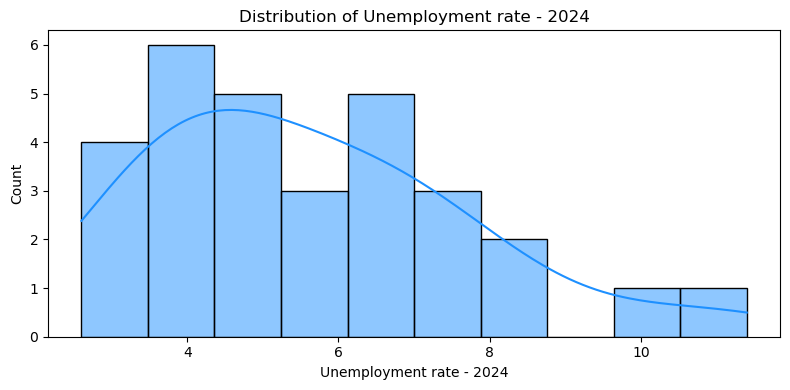

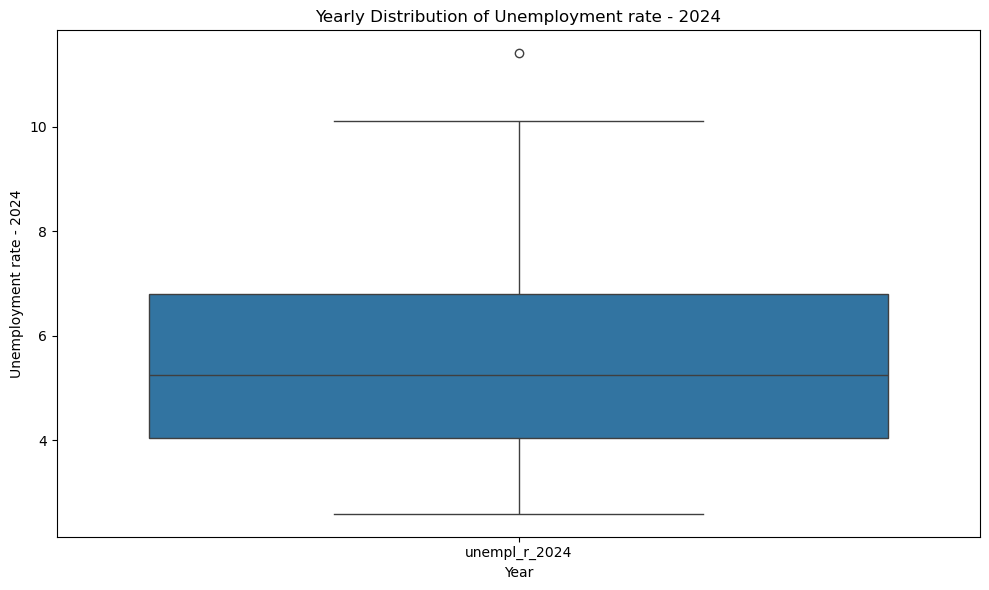

In [47]:
df = unempl_r

df_long = df.melt(id_vars=["geo"], 
                  value_vars=["unempl_r_2024"],
                  var_name="year",
                  value_name="unempl_r")

# Descriptive statistics (overall)
desc = df_long["unempl_r"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["unempl_r"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Unemployment rate - 2024")
plt.xlabel("Unemployment rate - 2024")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="unempl_r", data=df_long)
plt.title("Yearly Distribution of Unemployment rate - 2024")
plt.xlabel("Year")
plt.ylabel("Unemployment rate - 2024")
plt.tight_layout()
plt.show()

### Inflation rate 

In [48]:
infl_r = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/infl_r.csv')

# Filter 
# unit RCH_A_AVG Annual average rate of change
# CP00 - All items HICP (harmonised index of consumer prices)

infl_r = infl_r.drop(columns=['freq', 'unit', 'coicop',  'flag_2020', 'flag_2021', 'flag_2022', 'flag_2023', 'flag_2024'])
infl_r = infl_r[infl_r['geo'].isin(EU_EFTA)]
print(infl_r)

   geo  num_2020  num_2021  num_2022  num_2023  num_2024
1   AT       1.4       2.8       8.6       7.7       2.9
2   BE       0.4       3.2      10.3       2.3       4.3
3   BG       1.2       2.8      13.0       8.6       2.6
4   CH       NaN       0.5       2.7       2.3       1.1
5   CY       NaN       2.3       8.1       3.9       2.3
6   CZ       3.3       3.3      14.8      12.0       2.7
7   DE       0.4       3.2       8.7       6.0       2.5
8   DK       0.3       1.9       8.5       3.4       1.3
11  EE       NaN       4.5      19.4       9.1       3.7
12  EL       NaN       0.6       9.3       4.2       3.0
13  ES       NaN       3.0       8.3       3.4       2.9
15  FI       0.4       2.1       7.2       4.3       1.0
16  FR       0.5       2.1       5.9       5.7       2.3
17  HR       0.0       2.7      10.7       8.4       4.0
18  HU       3.4       5.2      15.3      17.0       3.7
19  IE       NaN       2.4       8.1       5.2       1.3
20  IS       1.2       3.7     

In [49]:
infl_r = infl_r.dropna()
infl_r.rename(columns={'num_2020': 'infl_r_2020', 'num_2021' : 'infl_r_2021', 'num_2022' : 'infl_r_2022', 'num_2023' : 'infl_r_2023','num_2024' : 'infl_r_2024' }, inplace=True)
print(infl_r)

   geo  infl_r_2020  infl_r_2021  infl_r_2022  infl_r_2023  infl_r_2024
1   AT          1.4          2.8          8.6          7.7          2.9
2   BE          0.4          3.2         10.3          2.3          4.3
3   BG          1.2          2.8         13.0          8.6          2.6
6   CZ          3.3          3.3         14.8         12.0          2.7
7   DE          0.4          3.2          8.7          6.0          2.5
8   DK          0.3          1.9          8.5          3.4          1.3
15  FI          0.4          2.1          7.2          4.3          1.0
16  FR          0.5          2.1          5.9          5.7          2.3
17  HR          0.0          2.7         10.7          8.4          4.0
18  HU          3.4          5.2         15.3         17.0          3.7
20  IS          1.2          3.7          5.7          8.0          4.5
22  LT          1.1          4.6         18.9          8.7          0.9
23  LU          0.0          3.5          8.2          2.9      

count    21.000000
mean      2.828571
std       1.230911
min       0.900000
25%       2.300000
50%       2.700000
75%       3.700000
max       5.800000
Name: infl_r, dtype: float64


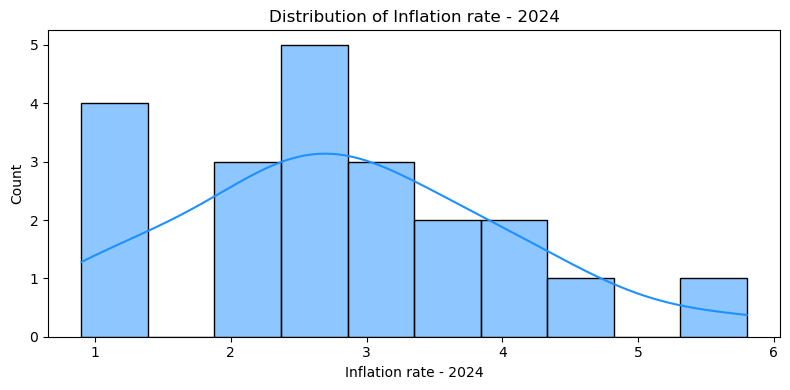

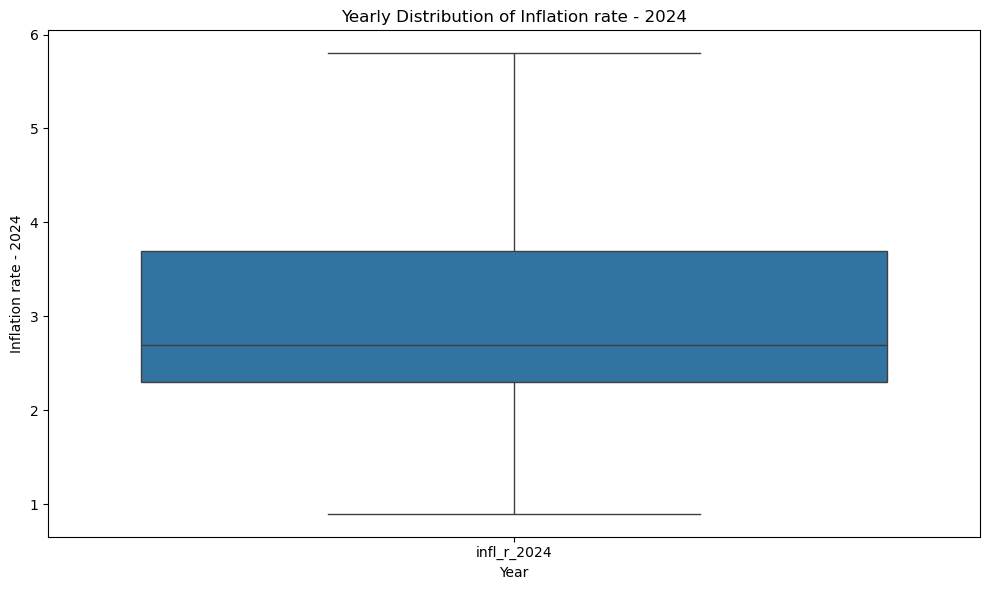

In [50]:
df = infl_r

df_long = df.melt(id_vars=["geo"], 
                  value_vars=["infl_r_2024"],
                  var_name="year",
                  value_name="infl_r")

# Descriptive statistics (overall)
desc = df_long["infl_r"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["infl_r"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Inflation rate - 2024")
plt.xlabel("Inflation rate - 2024")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="infl_r", data=df_long)
plt.title("Yearly Distribution of Inflation rate - 2024")
plt.xlabel("Year")
plt.ylabel("Inflation rate - 2024")
plt.tight_layout()
plt.show()

### GDP 

In [51]:
gdp = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/gdp.csv')

# Filter 

gdp = gdp.copy()
gdp = gdp[
    (gdp['na_item'] == 'B1GQ')& # Gross domestic product at market prices
    (gdp['unit'] == 'CP_EUR_HAB') # Current price, euro per capita
]


gdp = gdp.drop(columns=['freq', 'unit', 'na_item',  'flag_2020', 'flag_2021', 'flag_2022', 'flag_2023', 'flag_2024'])
gdp = gdp[gdp['geo'].isin(EU_EFTA)]
print(gdp)

     geo  num_2020  num_2021  num_2022  num_2023  num_2024
2545  AT   42650.0   45380.0   49640.0   52330.0   53830.0
2546  BE   40190.0   43680.0   48060.0   51140.0   52370.0
2547  BG    9440.0   10960.0   13310.0   14660.0   16260.0
2548  CH   75280.0   79140.0   89660.0   92760.0   96010.0
2549  CY   24630.0   27850.0   31560.0   33870.0   35730.0
2550  CZ   20980.0   23430.0   26670.0   29330.0   29440.0
2551  DE   42020.0   44910.0   48340.0   50660.0   51830.0
2552  DK   53540.0   58640.0   64430.0   62910.0   65650.0
2557  EE   20960.0   23650.0   27260.0   28080.0   28990.0
2558  EL   15660.0   17350.0   19570.0   21300.0   22480.0
2559  ES   23850.0   26090.0   28790.0   30980.0   32630.0
2561  FI   42740.0   44890.0   47890.0   48920.0   49100.0
2562  FR   34280.0   36920.0   38920.0   41340.0   42590.0
2563  HR   12980.0   15070.0   17540.0   20530.0   22200.0
2564  HU   14370.0   16090.0   17550.0   20560.0   21550.0
2565  IE   75820.0   88070.0  100140.0   99080.0  104510

In [52]:
gdp = gdp.dropna()
gdp.rename(columns={'num_2020': 'gdp_2020', 'num_2021' : 'gdp_2021', 'num_2022' : 'gdp_2022', 'num_2023' : 'gdp_2023','num_2024' : 'gdp_2024' }, inplace=True)
print(gdp)

     geo  gdp_2020  gdp_2021  gdp_2022  gdp_2023  gdp_2024
2545  AT   42650.0   45380.0   49640.0   52330.0   53830.0
2546  BE   40190.0   43680.0   48060.0   51140.0   52370.0
2547  BG    9440.0   10960.0   13310.0   14660.0   16260.0
2548  CH   75280.0   79140.0   89660.0   92760.0   96010.0
2549  CY   24630.0   27850.0   31560.0   33870.0   35730.0
2550  CZ   20980.0   23430.0   26670.0   29330.0   29440.0
2551  DE   42020.0   44910.0   48340.0   50660.0   51830.0
2552  DK   53540.0   58640.0   64430.0   62910.0   65650.0
2557  EE   20960.0   23650.0   27260.0   28080.0   28990.0
2558  EL   15660.0   17350.0   19570.0   21300.0   22480.0
2559  ES   23850.0   26090.0   28790.0   30980.0   32630.0
2561  FI   42740.0   44890.0   47890.0   48920.0   49100.0
2562  FR   34280.0   36920.0   38920.0   41340.0   42590.0
2563  HR   12980.0   15070.0   17540.0   20530.0   22200.0
2564  HU   14370.0   16090.0   17550.0   20560.0   21550.0
2565  IE   75820.0   88070.0  100140.0   99080.0  104510

count        30.000000
mean      45912.000000
std       27844.713409
min       16260.000000
25%       24652.500000
50%       36520.000000
75%       53495.000000
max      127030.000000
Name: gdp, dtype: float64


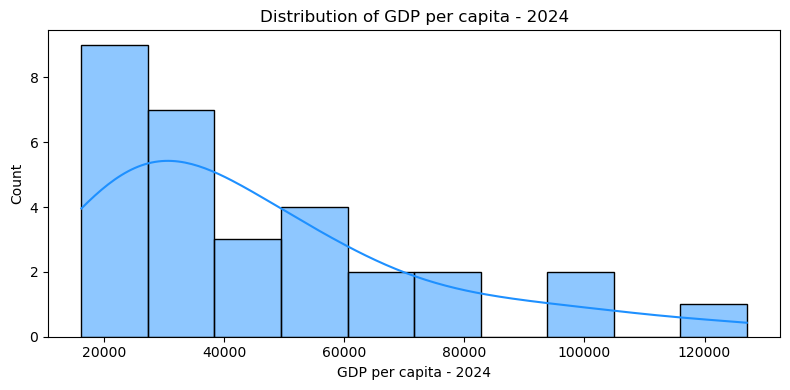

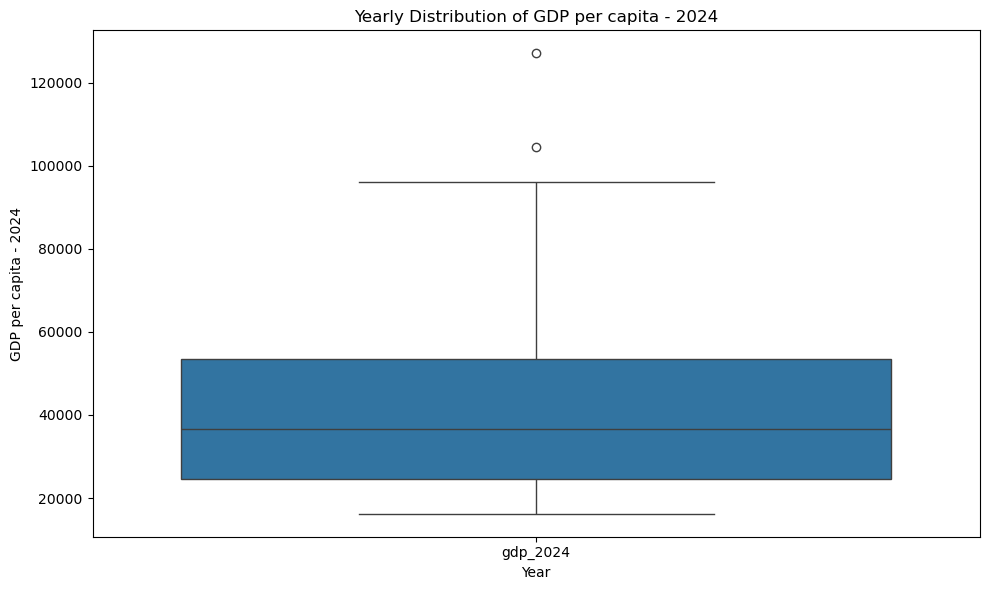

In [53]:
df = gdp

df_long = df.melt(id_vars=["geo"], 
                  value_vars=["gdp_2024"],
                  var_name="year",
                  value_name="gdp")

# Descriptive statistics (overall)
desc = df_long["gdp"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["gdp"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of GDP per capita - 2024")
plt.xlabel("GDP per capita - 2024")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="gdp", data=df_long)
plt.title("Yearly Distribution of GDP per capita - 2024")
plt.xlabel("Year")
plt.ylabel("GDP per capita - 2024")
plt.tight_layout()
plt.show()

### Productivity 



In [54]:
prodct = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/prodct.csv')

prodct['nace_r2_1d'] = prodct['nace_r2'].map(nace_section_or_nan)

prodct.drop(columns=['nace_r2'], inplace=True) 
prodct.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)
# print(occup)

# Filter 

prodct = prodct.copy()
prodct = prodct[
    (prodct['indic_sbs'] == 'LABPRY_TEUR')& # Apparent labour productivity – thousand euro (Value added (in thousand EUR) per person employed)
    (prodct['size_emp'] == 'TOTAL') 
]


prodct = prodct.drop(columns=['freq', 'indic_sbs', 'size_emp', 'flag_2021', 'flag_2022', 'flag_2023'])
prodct = prodct[prodct['geo'].isin(EU_EFTA)]
print(prodct)

            2021     2022      2023 geo  num_2021  num_2022  num_2023 nace_r2
789123   159.81   214.59    184.19   AT    159.81    214.59    184.19       B
789125   101.29   123.72    123.47   BE    101.29    123.72    123.47       B
789126    53.53    51.98     52.52   BG     53.53     51.98     52.52       B
789127  174.23 e     : @C  183.96 e  CH    174.23       NaN    183.96       B
789128    46.74    64.17     71.61   CY     46.74     64.17     71.61       B
...          ...      ...       ...  ..       ...       ...       ...     ...
850687    7.73 b    8.97      9.41   PT      7.73      8.97      9.41     NaN
850688    4.60 b    5.14      5.49   RO      4.60      5.14      5.49     NaN
850690    44.56    26.93     26.02   SE     44.56     26.93     26.02     NaN
850691    15.08    15.61     17.10   SI     15.08     15.61     17.10     NaN
850692     4.61     6.13      7.35   SK      4.61      6.13      7.35     NaN

[9895 rows x 8 columns]


In [55]:
prodct = prodct.dropna()
prodct.rename(columns={'num_2021' : 'prodct_2021', 'num_2022' : 'prodct_2022', 'num_2023' : 'prodct_2023' }, inplace=True)
print(prodct)

           2021     2022     2023 geo  prodct_2021  prodct_2022  prodct_2023  \
789123  159.81   214.59   184.19   AT       159.81       214.59       184.19   
789125  101.29   123.72   123.47   BE       101.29       123.72       123.47   
789126   53.53    51.98    52.52   BG        53.53        51.98        52.52   
789128   46.74    64.17    71.61   CY        46.74        64.17        71.61   
789129   56.82    81.70    92.33   CZ        56.82        81.70        92.33   
...         ...      ...      ...  ..          ...          ...          ...   
848072  20.35 b   26.39    26.94   PT        20.35        26.39        26.94   
848073  13.52 b   17.97    19.94   RO        13.52        17.97        19.94   
848075   55.73    29.90    27.91   SE        55.73        29.90        27.91   
848076   24.35    29.17    31.27   SI        24.35        29.17        31.27   
848077  117.30   118.07   130.89   SK       117.30       118.07       130.89   

       nace_r2  
789123       B  
78912

count     470.000000
mean       91.908787
std       131.054122
min         8.830000
25%        32.147500
50%        55.340000
75%       100.430000
max      1647.730000
Name: prodct, dtype: float64


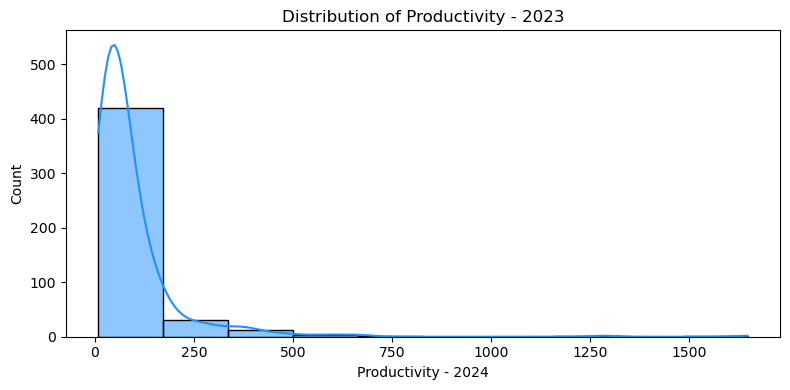

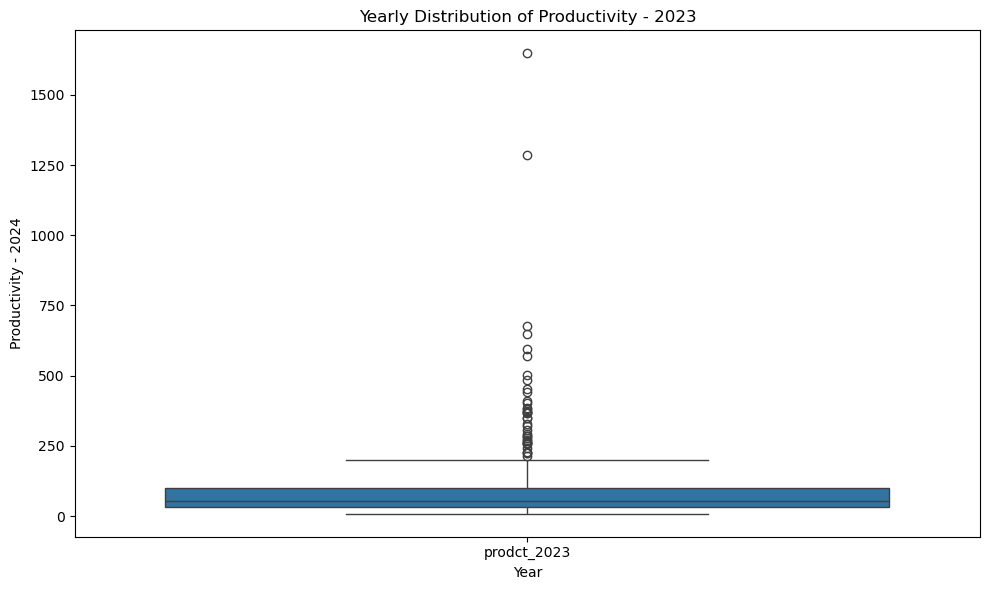

In [56]:
df = prodct

df_long = df.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=["prodct_2023"],
                  var_name="year",
                  value_name="prodct")

# Descriptive statistics (overall)
desc = df_long["prodct"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["prodct"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Productivity - 2023")
plt.xlabel("Productivity - 2024")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="prodct", data=df_long)
plt.title("Yearly Distribution of Productivity - 2023")
plt.xlabel("Year")
plt.ylabel("Productivity - 2024")
plt.tight_layout()
plt.show()

### Firm size

In [57]:
firm_s = pd.read_csv('C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/processed data/firm_s.csv')


print(firm_s)

        freq              indic_sbs nace_r2 size_emp geo  num_2021 flag_2021  \
0          A  AVG_EXPN_SAL_BEN_TEUR       B      0-9  AL      5.11       NaN   
1          A  AVG_EXPN_SAL_BEN_TEUR       B      0-9  AT     49.73       NaN   
2          A  AVG_EXPN_SAL_BEN_TEUR       B      0-9  BA      7.26       NaN   
3          A  AVG_EXPN_SAL_BEN_TEUR       B      0-9  BE     45.15       NaN   
4          A  AVG_EXPN_SAL_BEN_TEUR       B      0-9  BG     12.48       NaN   
...      ...                    ...     ...      ...  ..       ...       ...   
1406053    A              WAGE_MEUR    S960    TOTAL  RO    199.03       NaN   
1406054    A              WAGE_MEUR    S960    TOTAL  RS     43.30         b   
1406055    A              WAGE_MEUR    S960    TOTAL  SE    863.44       NaN   
1406056    A              WAGE_MEUR    S960    TOTAL  SI     65.60       NaN   
1406057    A              WAGE_MEUR    S960    TOTAL  SK     46.87       NaN   

         num_2022 flag_2022  num_2023 f

In [58]:
# --- FSI Calculation ---

# 1. Filter for the relevant indicator: Persons employed (EMP_NR)
df_emp = firm_s[firm_s['indic_sbs'] == 'EMP_NR'].copy()

# 2. Filter for relevant size classes: GE250 (Numerator) and TOTAL (Denominator)
df_fsi = df_emp[df_emp['size_emp'].isin(['GE250', 'TOTAL'])].copy()

# 3. Pivot the data to get size classes as columns
df_fsi_pivoted = df_fsi.pivot_table(
    index=['geo', 'nace_r2'],
    columns='size_emp',
    values='num_2023',  # Use the correct year column
    aggfunc='sum'
).reset_index()

# 4. Rename columns for clarity (assuming 'TOTAL' and 'GE250' exist)
df_fsi_pivoted.rename(columns={'GE250': 'Emp_250_plus', 'TOTAL': 'Emp_Total'}, inplace=True)

# 5. Calculate the Firm Size Index (FSI) as a percentage
df_fsi_pivoted['FSI'] = (df_fsi_pivoted['Emp_250_plus'] / df_fsi_pivoted['Emp_Total']) * 100

# Select final columns for merging
df_fsi_final = df_fsi_pivoted[['geo', 'nace_r2', 'FSI']]

print("FSI Calculation Head:")
print(df_fsi_final)

FSI Calculation Head:
size_emp geo      nace_r2        FSI
0         AL            B   0.000000
1         AL  B-S_X_O_S94  17.471183
2         AL          B05        NaN
3         AL         B051        NaN
4         AL         B052        NaN
...       ..          ...        ...
11928     SK          S95   0.000000
11929     SK         S951   0.000000
11930     SK         S952   0.000000
11931     SK          S96   0.000000
11932     SK         S960   0.000000

[11933 rows x 3 columns]


In [59]:
df_fsi_final['nace_r2_1d'] = df_fsi_final['nace_r2'].map(nace_section_or_nan)

df_fsi_final.drop(columns=['nace_r2'], inplace=True) 
df_fsi_final.rename(columns={'nace_r2_1d' : 'nace_r2'}, inplace=True)

df_fsi_final = df_fsi_final.dropna()
print(df_fsi_final)

size_emp geo        FSI nace_r2
0         AL   0.000000       B
16        AL  24.239152       C
112       AL   0.000000       D
117       AL  57.784000       E
127       AL  15.717109       F
...       ..        ...     ...
11848     SK   9.850670       M
11871     SK  16.367565       N
11897     SK   0.000000       P
11905     SK  37.841357       Q
11918     SK   0.000000       R

[556 rows x 3 columns]


C:\Users\ydmar\AppData\Local\Temp\ipykernel_24864\2442094143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fsi_final['nace_r2_1d'] = df_fsi_final['nace_r2'].map(nace_section_or_nan)
C:\Users\ydmar\AppData\Local\Temp\ipykernel_24864\2442094143.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fsi_final.drop(columns=['nace_r2'], inplace=True)
C:\Users\ydmar\AppData\Local\Temp\ipykernel_24864\2442094143.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.

count    556.000000
mean      28.196320
std       22.277461
min        0.000000
25%        9.639783
50%       25.086999
75%       44.052541
max       94.309497
Name: fsi, dtype: float64


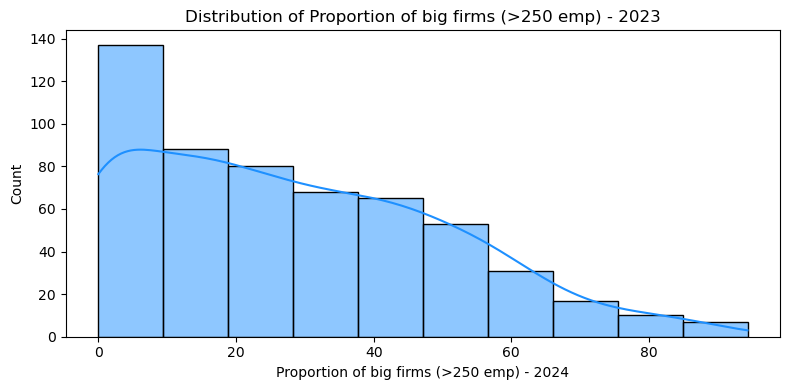

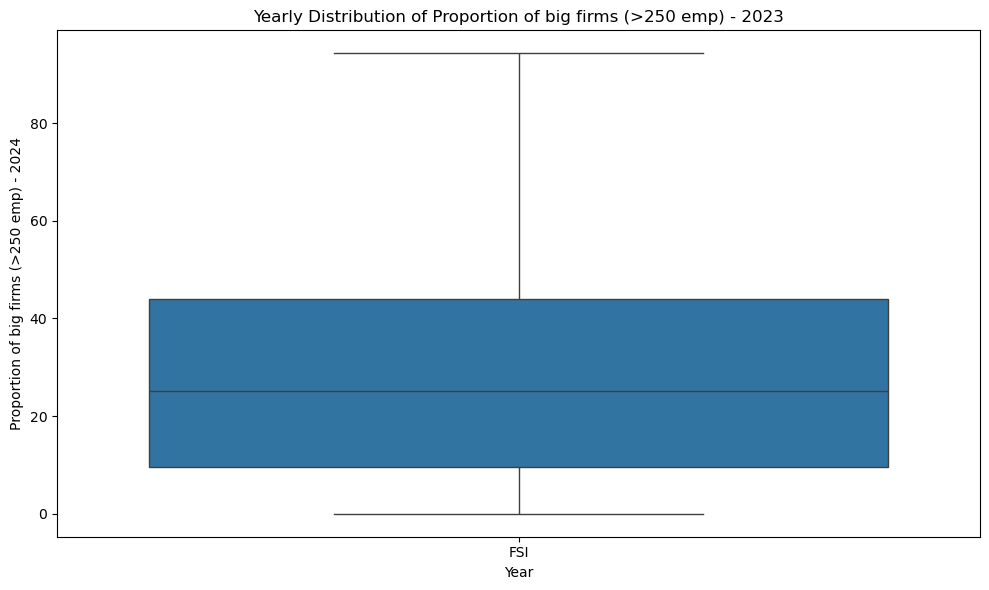

In [60]:
df = df_fsi_final

df_long = df.melt(id_vars=["geo", "nace_r2"], 
                  value_vars=["FSI"],
                  var_name="year",
                  value_name="fsi")

# Descriptive statistics (overall)
desc = df_long["fsi"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(df_long["fsi"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Proportion of big firms (>250 emp) - 2023")
plt.xlabel("Proportion of big firms (>250 emp) - 2024")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="fsi", data=df_long)
plt.title("Yearly Distribution of Proportion of big firms (>250 emp) - 2023")
plt.xlabel("Year")
plt.ylabel("Proportion of big firms (>250 emp) - 2024")
plt.tight_layout()
plt.show()

## Models 

### Data preparation and analysis - Baseline models 

In [61]:
wage_long = wg.melt(id_vars=['geo','nace_r2'], value_vars=['wg_2020','wg_2021','wg_2022','wg_2023','wg_2024'], var_name='year', value_name='wage')
wage_long['year'] = wage_long['year'].str.extract('([0-9]+)').astype(int)
print(wage_long['year'].unique())

[2020 2021 2022 2023 2024]


In [62]:
tr_long = tr.melt(id_vars=['geo','nace_r2'], value_vars=['tr_2020','tr_2022','tr_2024'], var_name='year', value_name='ict_tr')
tr_long['year'] = tr_long['year'].str.extract('([0-9]+)').astype(int)
print(tr_long['year'].unique())

[2020 2022 2024]


In [63]:
spec_long = ict_emp.melt(id_vars=['geo','nace_r2'], value_vars=['spec_2020','spec_2022','spec_2024'], var_name='year', value_name='ict_spec')
spec_long['year'] = spec_long['year'].str.extract('([0-9]+)').astype(int)
print(spec_long['year'].unique())

[2020 2022 2024]


In [64]:
ai_long = ai_adopt.melt(id_vars=['geo','nace_r2'], value_vars=['ai_2021','ai_2023','ai_2024'], var_name='year', value_name='ai_rate')
ai_long['year'] = ai_long['year'].str.extract('([0-9]+)').astype(int)
print(ai_long['year'].unique())

[2021 2023 2024]


In [65]:
educ_long = educ.melt(id_vars=['geo','nace_r2'], value_vars=['educ_2020', 'educ_2021', 'educ_2022', 'educ_2023','educ_2024'], var_name='year', value_name='educ')
educ_long['year'] = educ_long['year'].str.extract('([0-9]+)').astype(int)
print(educ_long['year'].unique())

[2020 2021 2022 2023 2024]


In [66]:
occup_long = occup.melt(id_vars=['geo','nace_r2'], value_vars=['occup_2020', 'occup_2021', 'occup_2022', 'occup_2023','occup_2024'], var_name='year', value_name='occup')
occup_long['year'] = occup_long['year'].str.extract('([0-9]+)').astype(int)
print(occup_long['year'].unique())

[2020 2021 2022 2023 2024]


In [67]:
unempl_r_long = unempl_r.melt(id_vars=['geo'], value_vars=['unempl_r_2020', 'unempl_r_2021', 'unempl_r_2022', 'unempl_r_2023','unempl_r_2024'], var_name='year', value_name='unempl_r')
unempl_r_long['year'] = unempl_r_long['year'].str.extract('([0-9]+)').astype(int)
print(unempl_r_long['year'].unique())

[2020 2021 2022 2023 2024]


In [68]:
infl_r_long = infl_r.melt(id_vars=['geo'], value_vars=['infl_r_2020', 'infl_r_2021', 'infl_r_2022', 'infl_r_2023','infl_r_2024'], var_name='year', value_name='infl_r')
infl_r_long['year'] = infl_r_long['year'].str.extract('([0-9]+)').astype(int)
print(infl_r_long['year'].unique())

[2020 2021 2022 2023 2024]


In [69]:
gdp_long = gdp.melt(id_vars=['geo'], value_vars=['gdp_2020', 'gdp_2021', 'gdp_2022', 'gdp_2023','gdp_2024'], var_name='year', value_name='gdp')
gdp_long['year'] = gdp_long['year'].str.extract('([0-9]+)').astype(int)
print(gdp_long['year'].unique())

[2020 2021 2022 2023 2024]


In [70]:
print(prodct)

           2021     2022     2023 geo  prodct_2021  prodct_2022  prodct_2023  \
789123  159.81   214.59   184.19   AT       159.81       214.59       184.19   
789125  101.29   123.72   123.47   BE       101.29       123.72       123.47   
789126   53.53    51.98    52.52   BG        53.53        51.98        52.52   
789128   46.74    64.17    71.61   CY        46.74        64.17        71.61   
789129   56.82    81.70    92.33   CZ        56.82        81.70        92.33   
...         ...      ...      ...  ..          ...          ...          ...   
848072  20.35 b   26.39    26.94   PT        20.35        26.39        26.94   
848073  13.52 b   17.97    19.94   RO        13.52        17.97        19.94   
848075   55.73    29.90    27.91   SE        55.73        29.90        27.91   
848076   24.35    29.17    31.27   SI        24.35        29.17        31.27   
848077  117.30   118.07   130.89   SK       117.30       118.07       130.89   

       nace_r2  
789123       B  
78912

In [71]:
prodct_long = prodct.melt(id_vars=['geo','nace_r2'], value_vars=['prodct_2021', 'prodct_2022', 'prodct_2023'], var_name='year', value_name='prodct')
prodct_long['year'] = prodct_long['year'].str.extract('([0-9]+)').astype(int)
print(prodct_long['year'].unique())

[2021 2022 2023]


In [72]:
prodct_2023 = prodct_long[prodct_long['year'] == 2023][['geo', 'nace_r2', 'prodct']]
wage_2024 = wage_long[wage_long['year'] == 2024][['geo', 'nace_r2', 'wage']]
ai_2024 = ai_long[ai_long['year'] == 2024][['geo', 'nace_r2', 'ai_rate']]
train_2024 = tr_long[tr_long['year'] == 2024][['geo', 'nace_r2', 'ict_tr']]
spec_2024 = spec_long[spec_long['year'] == 2024][['geo', 'nace_r2', 'ict_spec']]
educ_2024 = educ_long[educ_long['year'] == 2024][['geo', 'nace_r2', 'educ']]
occup_2024 = occup_long[occup_long['year'] == 2024][['geo', 'nace_r2', 'occup']]
unempl_r_2024 = unempl_r_long[unempl_r_long['year'] == 2024][['geo', 'unempl_r']]
infl_r_2024 = infl_r_long[infl_r_long['year'] == 2024][['geo', 'infl_r']]
gdp_2024 = gdp_long[gdp_long['year'] == 2024][['geo', 'gdp']]

In [73]:
# MODEL 1 dataframe 
from functools import reduce

# List all sector-by-country dataframes for variables in Model 1
dfs_m1 = [wage_2024, educ_2024, prodct_2023, share_high_skill_df, df_fsi_final] 

df_model_1 = reduce(lambda left, right: pd.merge(left, right, on=['geo', 'nace_r2']), dfs_m1)

# Now add macro-level controls (country-only)
df_model_1 = pd.merge(df_model_1, unempl_r_2024, on='geo', how='left')
df_model_1 = pd.merge(df_model_1, infl_r_2024, on='geo', how='left')
df_model_1 = pd.merge(df_model_1, gdp_2024, on='geo', how='left')

print(df_model_1.head())

  geo nace_r2  wage  educ  prodct  share_high_skill        FSI  unempl_r  \
0  AT       C  36.3  35.8   97.68         40.126825  57.515861       5.2   
1  BE       C  38.1  41.0  148.33         41.485958  49.308853       5.7   
2  BG       C   7.9  18.9   23.11         20.620251  36.395969       4.2   
3  CY       C  11.9  36.9   42.75         30.851064  19.474453       4.9   
4  CZ       C  13.4  14.1   43.66         27.347559  45.705806       2.6   

   infl_r      gdp  
0     2.9  53830.0  
1     4.3  52370.0  
2     2.6  16260.0  
3     NaN  35730.0  
4     2.7  29440.0  


In [74]:
duplicates = df_model_1[df_model_1.duplicated(subset=['geo', 'nace_r2'], keep=False)]
print(duplicates)

aggregated = df_model_1.groupby(['geo', 'nace_r2'], as_index=False).agg({
    'wage': 'mean',
    'educ': 'mean',     
    'prodct': 'mean',
    'share_high_skill': 'mean',
    'unempl_r': 'mean',
    'infl_r': 'mean',
    'gdp': 'mean',
    'wage': 'mean',
    'FSI': 'mean'
})

print(aggregated.shape)
print(aggregated.head())

Empty DataFrame
Columns: [geo, nace_r2, wage, educ, prodct, share_high_skill, FSI, unempl_r, infl_r, gdp]
Index: []
(261, 10)
  geo nace_r2  wage  educ  prodct  share_high_skill  unempl_r  infl_r  \
0  AT       C  36.3  35.8   97.68         40.126825       5.2     2.9   
1  AT       F  28.4  24.4   72.19         29.300743       5.2     2.9   
2  AT       G  27.7  22.4   65.77         26.423257       5.2     2.9   
3  AT       H  29.9  23.2   82.22         23.230844       5.2     2.9   
4  AT       J  44.1  66.8   94.04         89.534884       5.2     2.9   

       gdp        FSI  
0  53830.0  57.515861  
1  53830.0  22.051368  
2  53830.0  38.560073  
3  53830.0  45.650485  
4  53830.0  29.231095  


In [75]:
# Add log wage for regression
aggregated['log_wage_ij'] = np.log(aggregated['wage'])
aggregated['log_gdp_i'] = np.log(aggregated['gdp'])
aggregated['log_prdct_ij'] = np.log(aggregated['prodct'])
print(aggregated)

    geo nace_r2  wage  educ  prodct  share_high_skill  unempl_r  infl_r  \
0    AT       C  36.3  35.8   97.68         40.126825       5.2     2.9   
1    AT       F  28.4  24.4   72.19         29.300743       5.2     2.9   
2    AT       G  27.7  22.4   65.77         26.423257       5.2     2.9   
3    AT       H  29.9  23.2   82.22         23.230844       5.2     2.9   
4    AT       J  44.1  66.8   94.04         89.534884       5.2     2.9   
..   ..     ...   ...   ...     ...               ...       ...     ...   
256  SI       Q  20.9  49.7   36.72         64.080100       3.7     NaN   
257  SK       C  13.0  17.4   38.13         25.630178       5.3     3.2   
258  SK       F  11.9  16.1   18.12         24.281884       5.3     3.2   
259  SK       G  12.1  19.8   31.02         23.282083       5.3     3.2   
260  SK       J  21.0  70.1   51.81         85.416667       5.3     3.2   

         gdp        FSI  log_wage_ij  log_gdp_i  log_prdct_ij  
0    53830.0  57.515861     3.59181

In [76]:
aggregated = aggregated.rename(columns={'wage' : 'wage_ij', 'educ' : 'educ_ij','prodct' : 'prodct_ij', 
                                        'share_high_skill' : 'h_skill_ij', 'unempl_r' : 'unempl_r_i', 'infl_r' : 'infl_r_i', 'gdp' : 'gdp_i', 'FSI' : 'fsi_ij'})

print(aggregated)

    geo nace_r2  wage_ij  educ_ij  prodct_ij  h_skill_ij  unempl_r_i  \
0    AT       C     36.3     35.8      97.68   40.126825         5.2   
1    AT       F     28.4     24.4      72.19   29.300743         5.2   
2    AT       G     27.7     22.4      65.77   26.423257         5.2   
3    AT       H     29.9     23.2      82.22   23.230844         5.2   
4    AT       J     44.1     66.8      94.04   89.534884         5.2   
..   ..     ...      ...      ...        ...         ...         ...   
256  SI       Q     20.9     49.7      36.72   64.080100         3.7   
257  SK       C     13.0     17.4      38.13   25.630178         5.3   
258  SK       F     11.9     16.1      18.12   24.281884         5.3   
259  SK       G     12.1     19.8      31.02   23.282083         5.3   
260  SK       J     21.0     70.1      51.81   85.416667         5.3   

     infl_r_i    gdp_i     fsi_ij  log_wage_ij  log_gdp_i  log_prdct_ij  
0         2.9  53830.0  57.515861     3.591818  10.893586    

In [77]:
duplicates = aggregated[aggregated.duplicated()]
print(duplicates)
df_model_1 = aggregated.copy()
# df_model_1 = df_model_1.drop(columns=['wage_ij', 'prodct_ij', 'gdp_i'], axis=1)
df_model_1 = df_model_1.dropna()
print(df_model_1)

Empty DataFrame
Columns: [geo, nace_r2, wage_ij, educ_ij, prodct_ij, h_skill_ij, unempl_r_i, infl_r_i, gdp_i, fsi_ij, log_wage_ij, log_gdp_i, log_prdct_ij]
Index: []
    geo nace_r2  wage_ij  educ_ij  prodct_ij  h_skill_ij  unempl_r_i  \
0    AT       C     36.3     35.8      97.68   40.126825         5.2   
1    AT       F     28.4     24.4      72.19   29.300743         5.2   
2    AT       G     27.7     22.4      65.77   26.423257         5.2   
3    AT       H     29.9     23.2      82.22   23.230844         5.2   
4    AT       J     44.1     66.8      94.04   89.534884         5.2   
..   ..     ...      ...      ...        ...         ...         ...   
247  SE       R     23.2     47.4      27.91   69.990030         8.4   
257  SK       C     13.0     17.4      38.13   25.630178         5.3   
258  SK       F     11.9     16.1      18.12   24.281884         5.3   
259  SK       G     12.1     19.8      31.02   23.282083         5.3   
260  SK       J     21.0     70.1      51.

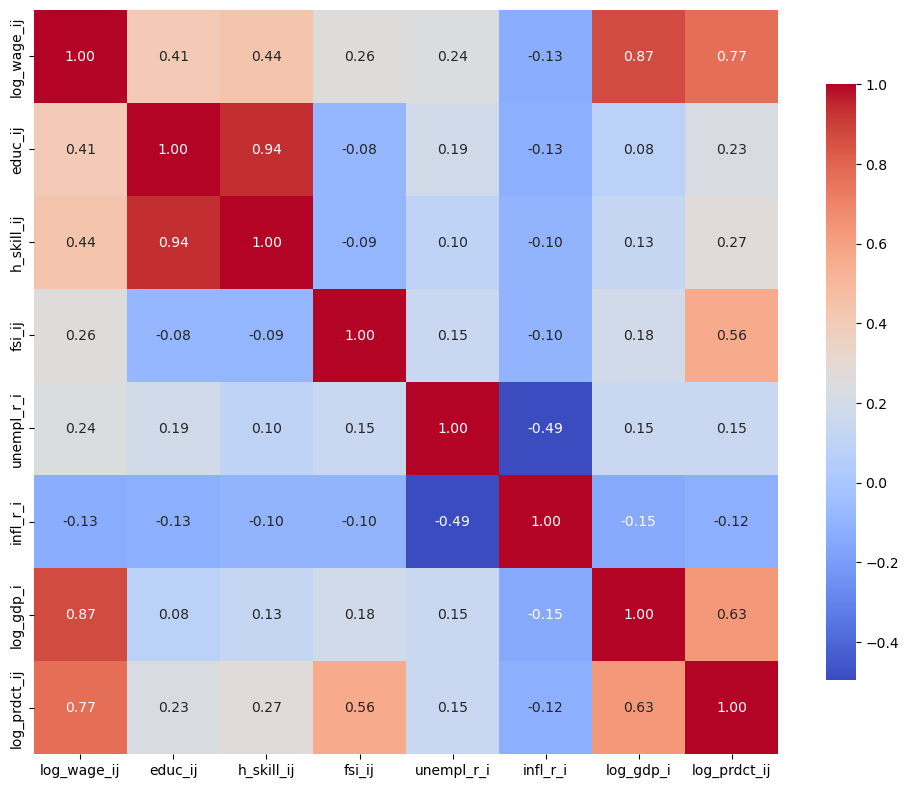

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose variables for the matrix
cols = [
    "log_wage_ij", "educ_ij", "h_skill_ij",
    "fsi_ij", "unempl_r_i", "infl_r_i", "log_gdp_i", "log_prdct_ij"
]

corr = df_model_1[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.tight_layout()
plt.show()


### Baseline models

In [79]:
import statsmodels.formula.api as smf

# Baseline models, country and sector FE included (GDP var. included)
model_1 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i + C(geo) + C(nace_r2)",
    data=df_model_1
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     135.8
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           3.80e-94
Time:                        11:25:11   Log-Likelihood:                 175.61
No. Observations:                 181   AIC:                            -275.2
Df Residuals:                     143   BIC:                            -153.7
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.4016      0.022    -

In [80]:
# Baseline model without FE
model_2 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + log_gdp_i",
    data=df_model_1
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     294.8
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.27e-92
Time:                        11:25:11   Log-Likelihood:                 82.591
No. Observations:                 181   AIC:                            -149.2
Df Residuals:                     173   BIC:                            -123.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -6.2603      0.300    -20.869   

In [81]:
# Baseline models, country and sector FE included (GDP var. excluded)
model_3 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(geo) + C(nace_r2)",
    data=df_model_1
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     135.8
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           3.80e-94
Time:                        11:25:11   Log-Likelihood:                 175.61
No. Observations:                 181   AIC:                            -275.2
Df Residuals:                     143   BIC:                            -153.7
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.1496      0.077     

In [82]:
# Baseline model without FE (GDP var. excluded)

model_4 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i",
    data=df_model_1
).fit()

print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     64.26
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.37e-41
Time:                        11:25:11   Log-Likelihood:                -43.327
No. Observations:                 181   AIC:                             100.7
Df Residuals:                     174   BIC:                             123.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.2653      0.184      1.440   

In [83]:
# Model Without macro param with FE

model_5 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + C(geo) + C(nace_r2)",
    data=df_model_1
).fit()

print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     135.8
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           3.80e-94
Time:                        11:25:11   Log-Likelihood:                 175.61
No. Observations:                 181   AIC:                            -275.2
Df Residuals:                     143   BIC:                            -153.7
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.8269      0.169     

In [84]:
# Model Without macro param without FE

model_6 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij",
    data=df_model_1
).fit()

print(model_6.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     90.62
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.10e-41
Time:                        11:25:11   Log-Likelihood:                -47.842
No. Observations:                 181   AIC:                             105.7
Df Residuals:                     176   BIC:                             121.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4920      0.145      3.403   

In [85]:
# Baseline comparison models 
# Better to use Model 4: there is no multicollinearity, used macro and wage controls

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

def has_country_fe(m):

    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[model_1, model_2,model_3, model_4, model_5, model_6],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(1) Baseline', '(2) Baseline (no FE)', '(3) Baseline (GDP excl) ', '(4) Baseline (no FE, GDP excl)', '(5) No macro controls', '(6) No macro controls (no FE)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                (1) Baseline (2) Baseline (no FE) (3) Baseline (GDP excl)  (4) Baseline (no FE, GDP excl) (5) No macro controls (6) No macro controls (no FE)
-------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept       -0.402***    -6.260***            1.150***                 0.265                          2.827***              0.492***                     
                (0.022)      (0.300)              (0.077)                  (0.184)                        (0.169)               (0.145)                      
C(geo)[T.BE]    0.124***                          -0.378***                                               0.018                                              
                (0.046)                           (0.053)                                                 (0.047)                                            
C(geo)[T.BG]    -0.800***                         -

### Data preparation and analysis - Models with AI variable

In [86]:
# --- 1. Merge Sector-Country Variables ---
dfs_m_ai = [wage_2024, ai_2024, train_2024, spec_2024, educ_2024, prodct_2023, share_high_skill_df, df_fsi_final] 

# Use 'outer' merge initially to prevent loss of data, then clean up missing values later
df_model_ai = reduce(lambda left, right: pd.merge(left, right, on=['geo', 'nace_r2'], how='outer'), dfs_m_ai)

# Now add macro-level controls (country-only)
df_model_ai = pd.merge(df_model_ai, unempl_r_2024, on='geo', how='left')
df_model_ai = pd.merge(df_model_ai, infl_r_2024, on='geo', how='left')


duplicates = df_model_ai[df_model_ai.duplicated(subset=['geo', 'nace_r2'], keep=False)]
print(duplicates)


Empty DataFrame
Columns: [geo, nace_r2, wage, ai_rate, ict_tr, ict_spec, educ, prodct, share_high_skill, FSI, unempl_r, infl_r]
Index: []


In [87]:
aggregated = df_model_ai.groupby(['geo', 'nace_r2'], as_index=False).agg({
    'wage': 'mean',
    'ai_rate': 'mean',
    'prodct': 'mean',
    'share_high_skill': 'mean',
    'ict_tr': 'mean',
    'ict_spec': 'mean',
    'educ': 'mean',  
    'FSI': 'mean',
    'unempl_r': 'mean',
    'infl_r': 'mean'
})

aggregated['log_wage_ij'] = np.log(aggregated['wage'])
aggregated['log_prdct_ij'] = np.log(aggregated['prodct'])


aggregated = aggregated.rename(columns={'ai_rate' : 'ai_ij', 'ict_tr' : 'ict_tr_ij', 'ict_spec' : 'ict_spec_ij','wage' : 'wage_ij', 'educ' : 'educ_ij','prodct' : 'prodct_ij', 
                                        'share_high_skill' : 'h_skill_ij', 'unempl_r' : 'unempl_r_i', 'infl_r' : 'infl_r_i', 'FSI' : 'fsi_ij'})

print(aggregated)

    geo nace_r2  wage_ij  ai_ij  prodct_ij  h_skill_ij  ict_tr_ij  \
0    AL       B      NaN    NaN        NaN         NaN        NaN   
1    AL       C      NaN    NaN        NaN         NaN        NaN   
2    AL       D      NaN    NaN        NaN         NaN        NaN   
3    AL       E      NaN    NaN        NaN         NaN        NaN   
4    AL       F      NaN    NaN        NaN         NaN        NaN   
..   ..     ...      ...    ...        ...         ...        ...   
653  SK       O      NaN    NaN        NaN   45.138227        NaN   
654  SK       P     13.1    NaN      14.80         NaN        NaN   
655  SK       Q     15.0    NaN      36.56         NaN        NaN   
656  SK       R     11.2    NaN     130.89         NaN        NaN   
657  SK       S      8.9    NaN        NaN         NaN        NaN   

     ict_spec_ij  educ_ij     fsi_ij  unempl_r_i  infl_r_i  log_wage_ij  \
0            NaN      NaN   0.000000         NaN       NaN          NaN   
1            NaN     

In [88]:
duplicates = aggregated[aggregated.duplicated()]
print(duplicates)
df_model_ai = aggregated.copy()
df_model_ai = df_model_ai.dropna()
print(df_model_ai)

Empty DataFrame
Columns: [geo, nace_r2, wage_ij, ai_ij, prodct_ij, h_skill_ij, ict_tr_ij, ict_spec_ij, educ_ij, fsi_ij, unempl_r_i, infl_r_i, log_wage_ij, log_prdct_ij]
Index: []
    geo nace_r2  wage_ij  ai_ij  prodct_ij  h_skill_ij  ict_tr_ij  \
17   AT       C     36.3  22.71      97.68   40.126825      26.06   
20   AT       F     28.4   7.35      72.19   29.300743       9.11   
21   AT       G     27.7  15.67      65.77   26.423257      19.51   
22   AT       H     29.9  13.48      82.22   23.230844      12.55   
28   AT       N     25.1  19.57      58.27   19.727891      16.68   
..   ..     ...      ...    ...        ...         ...        ...   
614  SE       N     23.3  21.63      45.64   34.011759      25.74   
641  SK       C     13.0   8.08      38.13   25.630178      16.79   
644  SK       F     11.9   6.31      18.12   24.281884       7.98   
645  SK       G     12.1  11.65      31.02   23.282083      19.87   
648  SK       J     21.0  29.19      51.81   85.416667      62

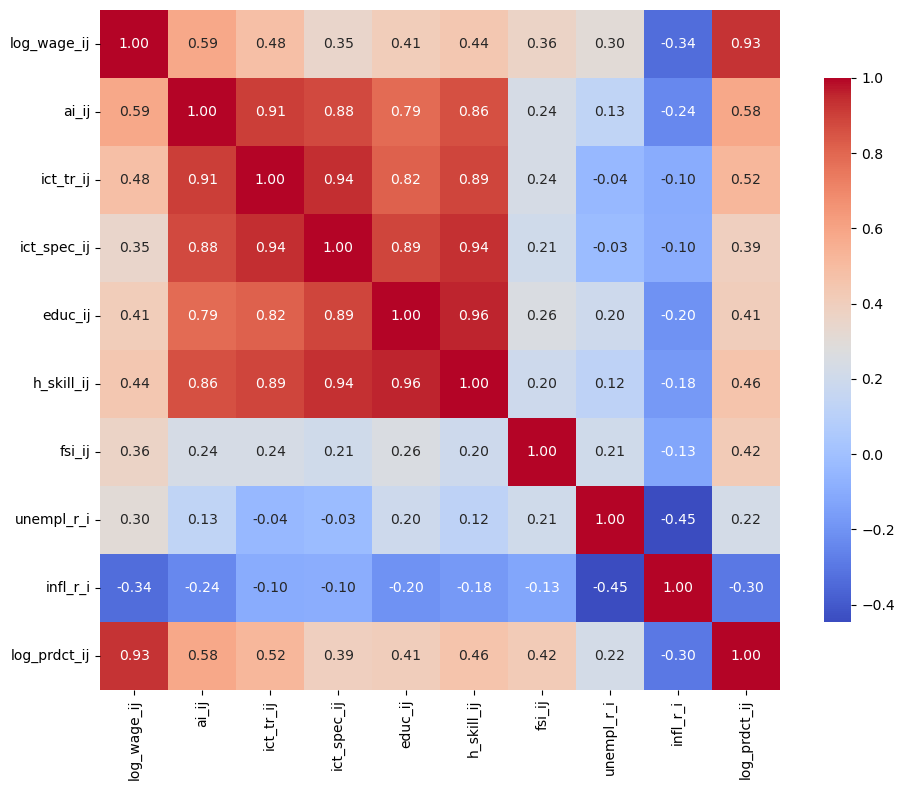

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose variables for the matrix
cols = [
    "log_wage_ij", "ai_ij", "ict_tr_ij", "ict_spec_ij", "educ_ij", "h_skill_ij",
    "fsi_ij", "unempl_r_i", "infl_r_i", "log_prdct_ij"
]

corr = df_model_ai[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.tight_layout()
plt.show()

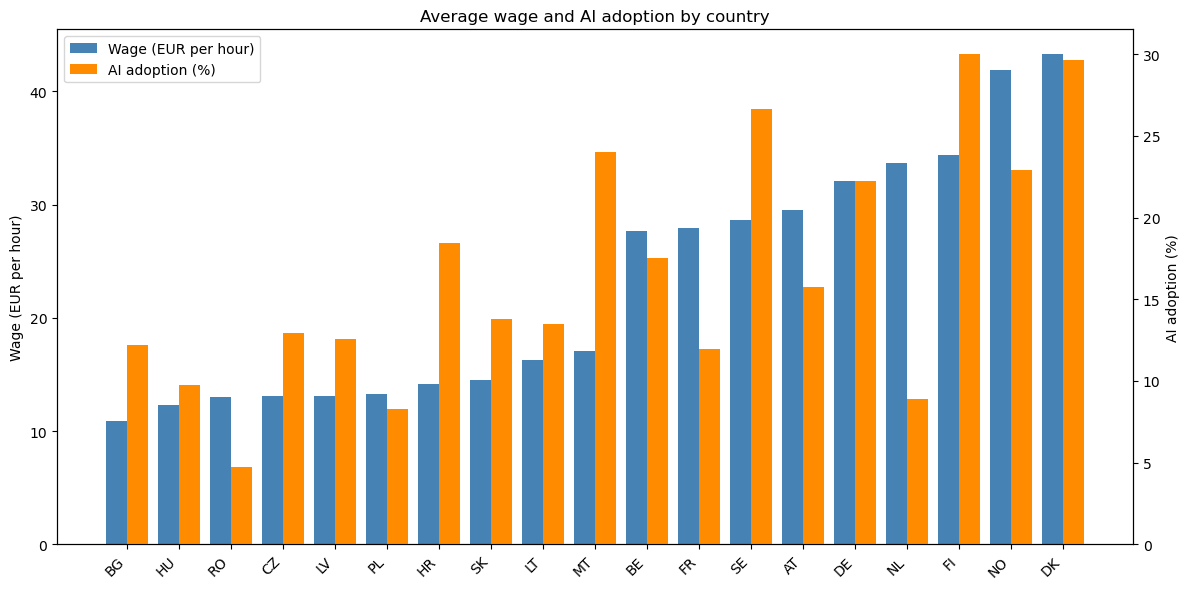

In [90]:
# If multiple sectors per country: average by country
df_country = df_model_ai.groupby('geo', as_index=False)[['wage_ij', 'ai_ij']].mean()

df_country = df_country.sort_values('wage_ij')  # or ai_rate

countries = df_country['geo'].values
wages = df_country['wage_ij'].values
ai = df_country['ai_ij'].values

x = np.arange(len(countries))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: wage bars
bars1 = ax1.bar(x - width/2, wages, width, color='steelblue',
                label='Wage (EUR per hour)')
ax1.set_ylabel('Wage (EUR per hour)')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Right axis: AI bars (different scale)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, ai, width, color='darkorange',
                label='AI adoption (%)')
ax2.set_ylabel('AI adoption (%)')

plt.title('Average wage and AI adoption by country')

# Combined legend
lines = [bars1, bars2]
labels = ['Wage (EUR per hour)', 'AI adoption (%)']
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

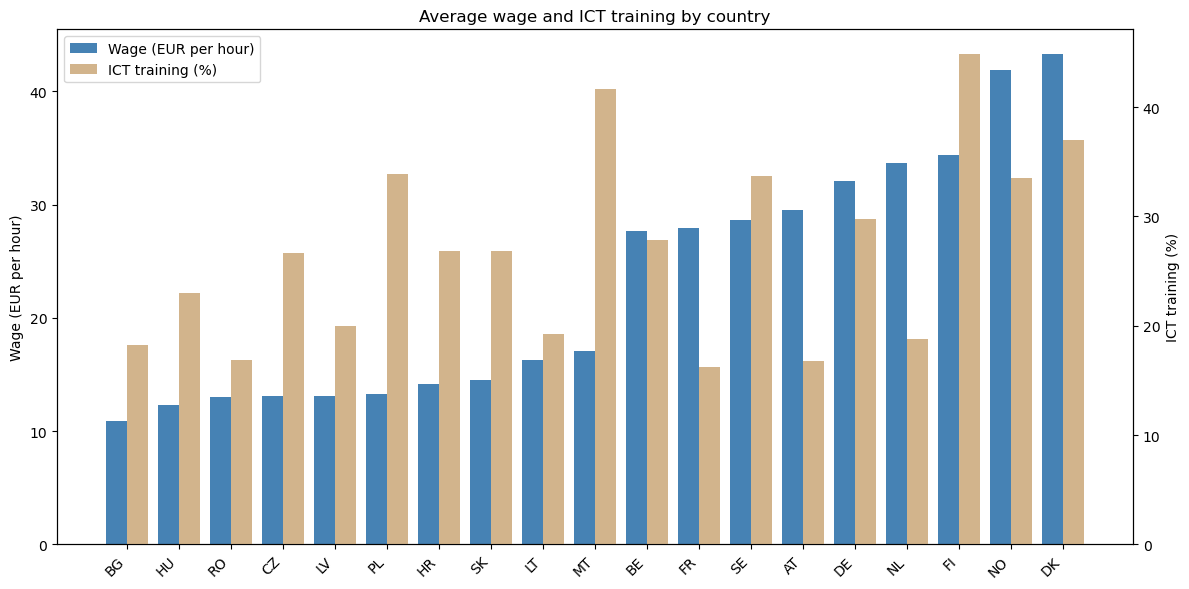

In [91]:
# If multiple sectors per country: average by country
df_country = df_model_ai.groupby('geo', as_index=False)[['wage_ij', 'ict_tr_ij']].mean()

df_country = df_country.sort_values('wage_ij')  # or ai_rate

countries = df_country['geo'].values
wages = df_country['wage_ij'].values
ict_tr = df_country['ict_tr_ij'].values

x = np.arange(len(countries))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: wage bars
bars1 = ax1.bar(x - width/2, wages, width, color='steelblue',
                label='Wage (EUR per hour)')
ax1.set_ylabel('Wage (EUR per hour)')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Right axis: AI bars (different scale)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, ict_tr, width, color='tan',
                label='ICT training (%)')
ax2.set_ylabel('ICT training (%)')

plt.title('Average wage and ICT training by country')

# Combined legend
lines = [bars1, bars2]
labels = ['Wage (EUR per hour)', 'ICT training (%)']
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()


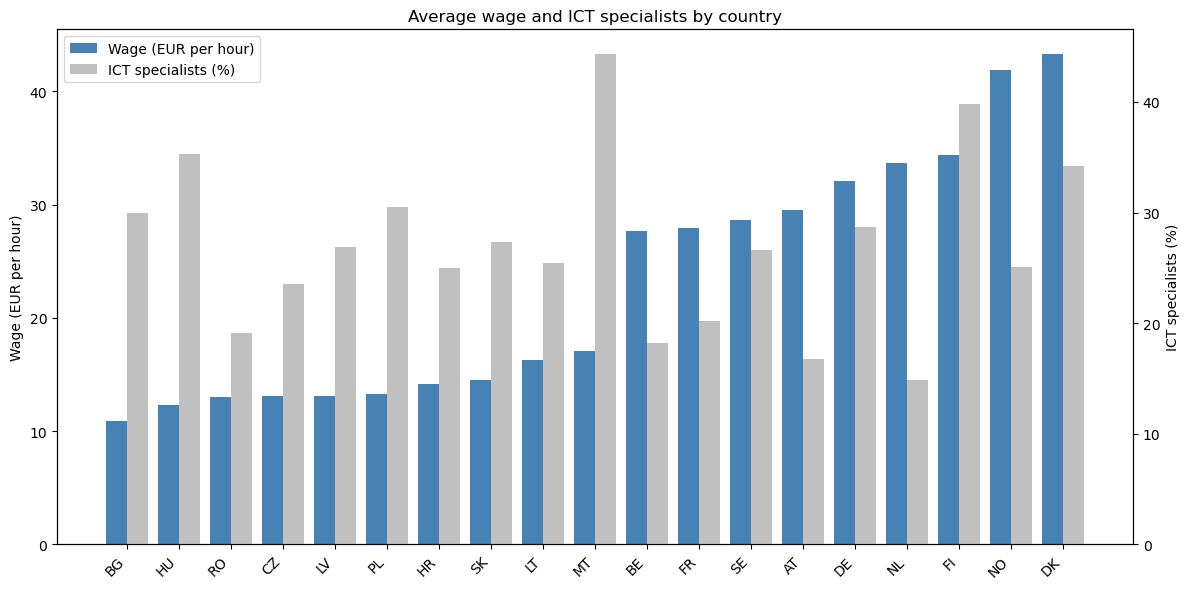

In [92]:
# If multiple sectors per country: average by country
df_country = df_model_ai.groupby('geo', as_index=False)[['wage_ij', 'ict_spec_ij']].mean()

df_country = df_country.sort_values('wage_ij')  # or ai_rate

countries = df_country['geo'].values
wages = df_country['wage_ij'].values
ict_spec = df_country['ict_spec_ij'].values

x = np.arange(len(countries))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: wage bars
bars1 = ax1.bar(x - width/2, wages, width, color='steelblue',
                label='Wage (EUR per hour)')
ax1.set_ylabel('Wage (EUR per hour)')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Right axis: AI bars (different scale)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, ict_spec, width, color='silver',
                label='ICT specialists (%)')
ax2.set_ylabel('ICT specialists (%)')

plt.title('Average wage and ICT specialists by country')

# Combined legend
lines = [bars1, bars2]
labels = ['Wage (EUR per hour)', 'ICT specialists (%)']
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()


### Models with AI variable (mostly without country FE)

In [93]:
# Model with purely AI (with sector FE) -- here the models does NOT faces multicollinearity 
model_7 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + ai_ij + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_7.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     62.49
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           8.66e-38
Time:                        11:25:17   Log-Likelihood:                 39.329
No. Observations:                  99   AIC:                            -50.66
Df Residuals:                      85   BIC:                            -14.33
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6250      0.214     

In [94]:
# Model with AI (without FE) -- here the models does NOT faces multicollinearity 
model_8 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + ai_ij",
    data=df_model_ai
).fit()

print(model_8.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     95.33
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           4.29e-39
Time:                        11:25:17   Log-Likelihood:                 27.614
No. Observations:                  99   AIC:                            -39.23
Df Residuals:                      91   BIC:                            -18.47
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.4436      0.197     -2.255   

In [95]:
# Model with AI, ICT specialist (without interaction, without high-skilled empl, with sector FE) -- here the models does NOT faces multicollinearity 
model_9 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_spec_ij + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_9.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     64.47
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           2.66e-38
Time:                        11:25:17   Log-Likelihood:                 40.724
No. Observations:                  99   AIC:                            -53.45
Df Residuals:                      85   BIC:                            -17.12
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.5148      0.220     

In [96]:
# Model with AI, ICT specialist (with interaction, without high-skilled empl, with sector FE) -- here the models does faces multicollinearity 
model_10 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_10.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     68.12
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.05e-39
Time:                        11:25:17   Log-Likelihood:                 47.104
No. Observations:                  99   AIC:                            -64.21
Df Residuals:                      84   BIC:                            -25.28
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

In [97]:
# Model with AI, ICT training (without interaction, without high-skilled empl, with sector FE) -- here the models does NOT faces multicollinearity
model_11 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_tr_ij + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_11.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     63.35
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           5.18e-38
Time:                        11:25:17   Log-Likelihood:                 39.936
No. Observations:                  99   AIC:                            -51.87
Df Residuals:                      85   BIC:                            -15.54
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6518      0.204     

In [98]:
# Model with AI, ICT training (with interaction, without high-skilled empl, with sector FE) -- here the models does faces multicollinearity
model_12 = smf.ols(
    formula="log_wage_ij ~ educ_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_12.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     66.97
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           2.00e-39
Time:                        11:25:17   Log-Likelihood:                 46.329
No. Observations:                  99   AIC:                            -62.66
Df Residuals:                      84   BIC:                            -23.73
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.5123 

In [99]:
# Model with AI, ICT specialists (without interaction, without education var, with sector FE) -- here the models does NOT faces multicollinearity (BUT WE REMOVED sector FE )
model_13 = smf.ols(
    formula="log_wage_ij ~ h_skill_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_spec_ij",
    data=df_model_ai
).fit()

print(model_13.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     101.4
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           3.69e-40
Time:                        11:25:17   Log-Likelihood:                 30.303
No. Observations:                  99   AIC:                            -44.61
Df Residuals:                      91   BIC:                            -23.85
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.2567      0.198     -1.295   

In [100]:
# Model with AI, ICT specialists (with interaction, without education var, with sector FE) -- here the models does faces multicollinearity
model_14 = smf.ols(
    formula="log_wage_ij ~ h_skill_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_14.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     65.28
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           5.28e-39
Time:                        11:25:17   Log-Likelihood:                 45.172
No. Observations:                  99   AIC:                            -60.34
Df Residuals:                      84   BIC:                            -21.42
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

In [101]:
# Model with AI, ICT training (without interaction, without education var, with sector FE) -- here the models does NOT faces multicollinearity
model_15 = smf.ols(
    formula="log_wage_ij ~ h_skill_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_tr_ij + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_15.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     61.11
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           2.03e-37
Time:                        11:25:17   Log-Likelihood:                 38.325
No. Observations:                  99   AIC:                            -48.65
Df Residuals:                      85   BIC:                            -12.32
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6742      0.214     

In [102]:
# Model with AI, ICT training (with interaction, without education var, with sector FE) -- here the models does faces multicollinearity
model_16 = smf.ols(
    formula="log_wage_ij ~ h_skill_ij + log_prdct_ij  + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2)",
    data=df_model_ai
).fit()

print(model_16.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     64.71
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           7.37e-39
Time:                        11:25:17   Log-Likelihood:                 44.773
No. Observations:                  99   AIC:                            -59.55
Df Residuals:                      84   BIC:                            -20.62
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.5267 

In [103]:
# Model with changes in AI (from 2023 to 2024)
ai_2023 = ai_long[ai_long['year'] == 2023][['geo', 'nace_r2', 'ai_rate']]
ai_2023 = ai_2023.rename(columns={'ai_rate': 'ai_2023'})
ai_2024 = ai_2024.rename(columns={'ai_rate': 'ai_2024'})

In [104]:
df_change = ai_2024.merge(ai_2023, on=['geo', 'nace_r2'], how='inner')
df_change['delta_ai'] = df_change['ai_2024'] - df_change['ai_2023']
print(df_change)

    geo nace_r2  ai_2024  ai_2023  delta_ai
0    AT       C    22.71    12.31     10.40
1    BE       C    23.24    15.31      7.93
2    BG       C     4.35     2.55      1.80
3    CY       C     2.98     3.81     -0.83
4    CZ       C     9.55     6.01      3.54
..   ..     ...      ...      ...       ...
233  PT       N    12.91    10.29      2.62
234  RO       N     5.30     1.57      3.73
235  SE       N    21.63     8.30     13.33
236  SI       N     7.65     3.22      4.43
237  SK       N    18.37    10.16      8.21

[238 rows x 5 columns]


In [105]:
df_model_change = df_model_ai.merge(
    df_change[['geo', 'nace_r2', 'delta_ai']],
    on=['geo', 'nace_r2'],
    how='inner'
)

In [106]:
# Model 17
model_delta_spec = smf.ols(
    formula="""
    log_wage_ij ~ delta_ai
                + ict_spec_ij
                + I(delta_ai * ict_spec_ij)
                + educ_ij
                + log_prdct_ij
                + fsi_ij
                + unempl_r_i
                + infl_r_i
                + C(nace_r2)
    """,
    data=df_model_change
).fit()

print(model_delta_spec.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     65.70
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           4.15e-39
Time:                        11:25:18   Log-Likelihood:                 45.458
No. Observations:                  99   AIC:                            -60.92
Df Residuals:                      84   BIC:                            -21.99
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [107]:
# Model 18
model_delta_tr = smf.ols(
    formula="""
    log_wage_ij ~ delta_ai
                + ict_tr_ij
                + I(delta_ai * ict_tr_ij)
                + educ_ij
                + log_prdct_ij
                + fsi_ij
                + unempl_r_i
                + infl_r_i
                + C(nace_r2)
    """,
    data=df_model_change
).fit()

print(model_delta_tr.summary())


                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     65.42
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           4.88e-39
Time:                        11:25:18   Log-Likelihood:                 45.265
No. Observations:                  99   AIC:                            -60.53
Df Residuals:                      84   BIC:                            -21.60
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [108]:
# Model 19 (not presented in the progress report)
model_delta_ai = smf.ols(
    formula="""
    log_wage_ij ~ delta_ai
                + ict_tr_ij
                + educ_ij
                + log_prdct_ij
                + fsi_ij
                + unempl_r_i
                + infl_r_i
                + C(nace_r2)
    """,
    data=df_model_change
).fit()

print(model_delta_ai.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     67.53
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           4.50e-39
Time:                        11:25:18   Log-Likelihood:                 42.818
No. Observations:                  99   AIC:                            -57.64
Df Residuals:                      85   BIC:                            -21.30
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6066      0.197     

In [109]:
def has_country_fe(m):

    return 'C(geo)' in m.model.formula

def has_sector_fe(m):
    return 'C(nace_r2)' in m.model.formula


# Note: Intercept is often omitted or placed in the info_dict if FE are used
results_table = summary_col(
    results=[model_7, model_8, model_9, model_10, model_11, model_12, model_13, model_14, model_15, model_16, model_delta_tr, model_delta_spec],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(7)', '(8)', '(9)', '(10)', '(11)', '(12)', '(13)', '(14)', '(15)', '(16)', '(17)', '(18)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                             (7)      (8)      (9)       (10)      (11)      (12)      (13)      (14)      (15)      (16)      (17)     (18)  
----------------------------------------------------------------------------------------------------------------------------------------------
Intercept                 -0.625*** -0.444** -0.515** -0.325    -0.652*** -0.512**  -0.257    -0.337    -0.674*** -0.527**  -0.555*** -0.450**
                          (0.214)   (0.197)  (0.220)  (0.215)   (0.204)   (0.196)   (0.198)   (0.225)   (0.214)   (0.207)   (0.195)   (0.207) 
C(nace_r2)[T.F]           0.441***           0.378*** 0.435***  0.433***  0.468***            0.410***  0.404***  0.442***  0.382***  0.355***
                          (0.108)            (0.113)  (0.108)   (0.108)   (0.102)             (0.110)   (0.108)   (0.103)   (0.099)   (0.107) 
C(nace_r2)[T.G]           0.195***           0.191*** 0.153**   0.210***  0.173**             0.158**   0.217***  0.179***  0.151**   0.141**

In [110]:
print(df_model_ai['nace_r2'].unique())

['C' 'F' 'G' 'H' 'N' 'I' 'J']


### Marginal effects

In [111]:
m10 = model_10

beta_ai = m10.params['ai_ij']
gamma_ai_ictspec = m10.params['I(ai_ij * ict_spec_ij)']

z = df_model_ai['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_ictspec * z_low
me_mean = beta_ai + gamma_ai_ictspec * z_mean
me_high = beta_ai + gamma_ai_ictspec * z_high

print("Model 10 – marginal effect of AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")

Model 10 – marginal effect of AI on log wage:
  At low ICT_spec (P25=12.43):  0.0247
  At mean ICT_spec (P50=17.41): 0.0236
  At high ICT_spec (P75=28.14): 0.0210


In [112]:
m12 = model_12
beta_ai = m12.params['ai_ij']
gamma_ai_icttr = m12.params['I(ai_ij * ict_tr_ij)']

z = df_model_ai['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_ai + gamma_ai_icttr * z_low
me_mean = beta_ai + gamma_ai_icttr * z_mean
me_high = beta_ai + gamma_ai_icttr * z_high

print("Model 12 – marginal effect of AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 12 – marginal effect of AI on log wage:
  At low ICT_tr (P25=13.87):  0.0252
  At mean ICT_tr (P50=19.87): 0.0236
  At high ICT_tr (P75=34.29): 0.0198


In [113]:
m17 = model_delta_spec
beta_dai = m17.params['delta_ai']
gamma_dai_icttr = m17.params['I(delta_ai * ict_spec_ij)']

z = df_model_change['ict_spec_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_dai + gamma_dai_icttr * z_low
me_mean = beta_dai + gamma_dai_icttr * z_mean
me_high = beta_dai + gamma_dai_icttr * z_high

print("Model 17 – marginal effect of delta AI on log wage:")
print(f"  At low ICT_spec (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_spec (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_spec (P75={z_high:.2f}): {me_high:.4f}")

Model 17 – marginal effect of delta AI on log wage:
  At low ICT_spec (P25=12.43):  0.0300
  At mean ICT_spec (P50=17.41): 0.0287
  At high ICT_spec (P75=28.14): 0.0259


In [114]:
m18 = model_delta_tr
beta_dai = m18.params['delta_ai']
gamma_dai_icttr = m18.params['I(delta_ai * ict_tr_ij)']

z = df_model_change['ict_tr_ij']
z_low, z_mean, z_high = np.percentile(z, [25, 50, 75])

me_low  = beta_dai + gamma_dai_icttr * z_low
me_mean = beta_dai + gamma_dai_icttr * z_mean
me_high = beta_dai + gamma_dai_icttr * z_high

print("Model 18 – marginal effect of delta AI on log wage:")
print(f"  At low ICT_tr (P25={z_low:.2f}):  {me_low:.4f}")
print(f"  At mean ICT_tr (P50={z_mean:.2f}): {me_mean:.4f}")
print(f"  At high ICT_tr (P75={z_high:.2f}): {me_high:.4f}")

Model 18 – marginal effect of delta AI on log wage:
  At low ICT_tr (P25=13.87):  0.0317
  At mean ICT_tr (P50=19.87): 0.0298
  At high ICT_tr (P75=34.29): 0.0252


### Try to reduce R-squre for the models (also mostly without country FE)

In [115]:
df_model_1.columns

Index(['geo', 'nace_r2', 'wage_ij', 'educ_ij', 'prodct_ij', 'h_skill_ij',
       'unempl_r_i', 'infl_r_i', 'gdp_i', 'fsi_ij', 'log_wage_ij', 'log_gdp_i',
       'log_prdct_ij'],
      dtype='object')

In [116]:
dfs_test = [ai_2024, train_2024, spec_2024, occup_2024, wage_2024, educ_2024, prodct_2023, share_high_skill_df, df_fsi_final] 
df_model_test = reduce(lambda left, right: pd.merge(left, right, on=['geo', 'nace_r2']), dfs_test)
# Now add macro-level controls (country-only)
df_model_test = pd.merge(df_model_test, unempl_r_2024, on='geo', how='left')
df_model_test = pd.merge(df_model_test, infl_r_2024, on='geo', how='left')
df_model_test = pd.merge(df_model_test, gdp_2024, on='geo', how='left')
print(df_model_test.head())

  geo nace_r2  ai_2024  ict_tr  ict_spec  occup  wage  educ  prodct  \
0  AT       C    22.71   26.06     30.02   48.5  36.3  35.8   97.68   
1  AT       C    22.71   26.06     30.02   86.9  36.3  35.8   97.68   
2  AT       C    22.71   26.06     30.02  136.7  36.3  35.8   97.68   
3  AT       C    22.71   26.06     30.02   57.6  36.3  35.8   97.68   
4  AT       C    22.71   26.06     30.02   29.3  36.3  35.8   97.68   

   share_high_skill        FSI  unempl_r  infl_r      gdp  
0         40.126825  57.515861       5.2     2.9  53830.0  
1         40.126825  57.515861       5.2     2.9  53830.0  
2         40.126825  57.515861       5.2     2.9  53830.0  
3         40.126825  57.515861       5.2     2.9  53830.0  
4         40.126825  57.515861       5.2     2.9  53830.0  


In [117]:
duplicates = df_model_test[df_model_test.duplicated(subset=['geo', 'nace_r2'], keep=False)]
print(duplicates)
aggregated = df_model_test.groupby(['geo', 'nace_r2'], as_index=False).agg({
    'wage': 'mean',
    'educ': 'mean',     
    'prodct': 'mean',
    'share_high_skill': 'mean',
    'unempl_r': 'mean',
    'infl_r': 'mean',
    'gdp': 'mean',
    'FSI': 'mean',
    'ai_2024': 'mean',
    'ict_tr': 'mean',
    'ict_spec': 'mean'
})
print(aggregated.shape)
print(aggregated.head())

     geo nace_r2  ai_2024  ict_tr  ict_spec  occup  wage  educ  prodct  \
0     AT       C    22.71   26.06     30.02   48.5  36.3  35.8   97.68   
1     AT       C    22.71   26.06     30.02   86.9  36.3  35.8   97.68   
2     AT       C    22.71   26.06     30.02  136.7  36.3  35.8   97.68   
3     AT       C    22.71   26.06     30.02   57.6  36.3  35.8   97.68   
4     AT       C    22.71   26.06     30.02   29.3  36.3  35.8   97.68   
...   ..     ...      ...     ...       ...    ...   ...   ...     ...   
1110  SE       N    21.63   25.74     11.41    7.6  23.3  30.7   45.64   
1111  SE       N    21.63   25.74     11.41   17.8  23.3  30.7   45.64   
1112  SE       N    21.63   25.74     11.41   14.1  23.3  30.7   45.64   
1113  SE       N    21.63   25.74     11.41   48.5  23.3  30.7   45.64   
1114  SE       N    21.63   25.74     11.41  221.1  23.3  30.7   45.64   

      share_high_skill        FSI  unempl_r  infl_r      gdp  
0            40.126825  57.515861       5.2     

In [118]:
aggregated['log_wage_ij'] = np.log(aggregated['wage'])
aggregated['log_gdp_i'] = np.log(aggregated['gdp'])
aggregated['log_prdct_ij'] = np.log(aggregated['prodct'])
print(aggregated)


aggregated = aggregated.rename(columns={'wage' : 'wage_ij', 'educ' : 'educ_ij','prodct' : 'prodct_ij', 'share_high_skill' : 'h_skill_ij', 'unempl_r' : 'unempl_r_i',
                                         'infl_r' : 'infl_r_i', 'gdp' : 'gdp_i', 'FSI' : 'fsi_ij', 'ai_rate' : 'ai_rate_ij', 'ict_tr' : 'ict_tr_ij', 'ict_spec' : 'ict_spec_ij'})
print(aggregated)


duplicates = aggregated[aggregated.duplicated()]
print(duplicates)
df_model_test = aggregated.copy()
# df_model_1 = df_model_1.drop(columns=['wage_ij', 'prodct_ij', 'gdp_i'], axis=1)
df_model_test = df_model_test.dropna()
print(df_model_test)

    geo nace_r2  wage  educ  prodct  share_high_skill  unempl_r  infl_r  \
0    AT       C  36.3  35.8   97.68         40.126825       5.2     2.9   
1    AT       F  28.4  24.4   72.19         29.300743       5.2     2.9   
2    AT       G  27.7  22.4   65.77         26.423257       5.2     2.9   
3    AT       H  29.9  23.2   82.22         23.230844       5.2     2.9   
4    AT       N  25.1  22.3   58.27         19.727891       5.2     2.9   
..   ..     ...   ...   ...     ...               ...       ...     ...   
130  SI       J  30.6  64.1   61.70         89.398281       3.7     NaN   
131  SK       C  13.0  17.4   38.13         25.630178       5.3     3.2   
132  SK       F  11.9  16.1   18.12         24.281884       5.3     3.2   
133  SK       G  12.1  19.8   31.02         23.282083       5.3     3.2   
134  SK       J  21.0  70.1   51.81         85.416667       5.3     3.2   

         gdp        FSI  ai_2024  ict_tr  ict_spec  log_wage_ij  log_gdp_i  \
0    53830.0  57.5158

In [119]:
df_model_test = df_model_test.rename(columns={'ai_2024' : 'ai_ij'})
df_model_test.columns

Index(['geo', 'nace_r2', 'wage_ij', 'educ_ij', 'prodct_ij', 'h_skill_ij',
       'unempl_r_i', 'infl_r_i', 'gdp_i', 'fsi_ij', 'ai_ij', 'ict_tr_ij',
       'ict_spec_ij', 'log_wage_ij', 'log_gdp_i', 'log_prdct_ij'],
      dtype='object')

In [120]:
# Model without productivity variable, -- here the models does NOT faces multicollinearity (BUT WE REMOVED sector FE )
model_r2_red_1 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij + log_gdp_i + ai_ij",
    data=df_model_test
).fit()

print(model_r2_red_1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     336.9
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.76e-50
Time:                        11:25:18   Log-Likelihood:                 44.150
No. Observations:                  99   AIC:                            -80.30
Df Residuals:                      95   BIC:                            -69.92
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.7428      0.458     -8.174   

In [121]:
# Model without productivity variable
# When we add log_gdp_i -> multicollinearity error appears
model_r2_red_2 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij + ai_ij + ict_spec_ij",
    data=df_model_test
).fit()

print(model_r2_red_2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     230.6
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.79e-43
Time:                        11:25:18   Log-Likelihood:                 27.318
No. Observations:                  99   AIC:                            -46.64
Df Residuals:                      95   BIC:                            -36.26
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.2164      0.166     -1.305   

In [142]:
model_r2_red_3 = smf.ols(
    formula="log_wage_ij ~  log_prdct_ij + ai_ij + ict_tr_ij",
    data=df_model_test
).fit()

print(model_r2_red_3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     217.3
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           2.11e-42
Time:                        12:08:55   Log-Likelihood:                 24.743
No. Observations:                  99   AIC:                            -41.49
Df Residuals:                      95   BIC:                            -31.11
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.3589      0.161     -2.227   

In [123]:
model_r2_red_4 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_spec_ij",
    data=df_model_test
).fit()

print(model_r2_red_4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     41.46
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.05e-13
Time:                        11:25:19   Log-Likelihood:                -46.520
No. Observations:                  99   AIC:                             99.04
Df Residuals:                      96   BIC:                             106.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.7376      0.060     45.899      

In [124]:
model_r2_red_5 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_tr_ij",
    data=df_model_test
).fit()

print(model_r2_red_5.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     26.77
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           5.75e-10
Time:                        11:25:19   Log-Likelihood:                -55.395
No. Observations:                  99   AIC:                             116.8
Df Residuals:                      96   BIC:                             124.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7274      0.078     34.983      0.0

In [125]:
# Adding interaction lead to the multicollinearity problem 
model_r2_red_6 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_spec_ij + C(nace_r2)",
    data=df_model_test
).fit()

print(model_r2_red_6.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     12.12
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.32e-11
Time:                        11:25:19   Log-Likelihood:                -41.145
No. Observations:                  99   AIC:                             100.3
Df Residuals:                      90   BIC:                             123.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.6774      0.168     

In [126]:
model_r2_red_7 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_tr_ij + C(nace_r2)",
    data=df_model_test
).fit()

print(model_r2_red_7.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     12.03
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.55e-11
Time:                        11:25:19   Log-Likelihood:                -41.333
No. Observations:                  99   AIC:                             100.7
Df Residuals:                      90   BIC:                             124.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.4047      0.139     

In [127]:
# Adding interaction lead to the multicollinearity problem 
model_r2_red_8 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2)",
    data=df_model_test
).fit()

print(model_r2_red_8.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     21.63
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           6.55e-19
Time:                        11:25:19   Log-Likelihood:                -19.950
No. Observations:                  99   AIC:                             59.90
Df Residuals:                      89   BIC:                             85.85
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [128]:
# Adding interaction lead to the multicollinearity problem 
model_r2_red_9 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) ",
    data=df_model_test
).fit()

print(model_r2_red_9.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     19.64
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.08e-17
Time:                        11:25:19   Log-Likelihood:                -23.189
No. Observations:                  99   AIC:                             66.38
Df Residuals:                      89   BIC:                             92.33
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.9743 

In [129]:
# Adding interaction lead to the multicollinearity problem 
model_r2_red_10 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_tr_ij + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(nace_r2)",
    data=df_model_test
).fit()

print(model_r2_red_10.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     18.77
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           3.38e-19
Time:                        11:25:19   Log-Likelihood:                -13.664
No. Observations:                  99   AIC:                             53.33
Df Residuals:                      86   BIC:                             87.07
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.0897      0.272     

In [130]:
# Adding interaction lead to the multicollinearity problem 
model_r2_red_11 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_spec_ij + fsi_ij + unempl_r_i + infl_r_i + C(nace_r2)",
    data=df_model_test
).fit()

print(model_r2_red_11.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     19.07
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           8.56e-19
Time:                        11:25:19   Log-Likelihood:                -16.597
No. Observations:                  99   AIC:                             57.19
Df Residuals:                      87   BIC:                             88.34
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.6238      0.271     

In [131]:
# Adding interaction lead to the multicollinearity problem 
model_r2_red_12 = smf.ols(
    formula="log_wage_ij ~  ai_ij + ict_spec_ij + h_skill_ij + unempl_r_i + infl_r_i + C(nace_r2)",
    data=df_model_test
).fit()

print(model_r2_red_12.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     11.58
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           5.62e-13
Time:                        11:25:19   Log-Likelihood:                -32.696
No. Observations:                  99   AIC:                             89.39
Df Residuals:                      87   BIC:                             120.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.8028      0.349     

In [132]:
# # Model without productivity variable, -- here the models does NOT faces multicollinearity (BUT WE REMOVED sector FE )
# model_r2_red_13 = smf.ols(
#     formula="log_wage_ij ~ h_skill_ij  + educ_ij + fsi_ij + unempl_r_i + infl_r_i + ai_ij + ict_spec_ij",
#     data=df_model_ai
# ).fit()

# print(model_r2_red_13.summary())

In [133]:
df = df_model_test.copy()

# mean‑center AI and ICT_tr
df['ai_c']      = df['ai_ij']      - df['ai_ij'].mean()
df['ict_tr_c']  = df['ict_tr_ij']  - df['ict_tr_ij'].mean()

model_10c = smf.ols(
    formula=(
        "log_wage_ij ~ ai_c + ict_tr_c + I(ict_tr_c * ai_c) "
    ),
    data=df
).fit()

print(model_10c.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     31.01
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           4.60e-14
Time:                        11:25:19   Log-Likelihood:                -43.543
No. Observations:                  99   AIC:                             95.09
Df Residuals:                      95   BIC:                             105.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              3.1722      0

In [134]:
# here is the multicollinearity issue
df['ict_spec_c']  = df['ict_spec_ij']  - df['ict_spec_ij'].mean()

model_10c2 = smf.ols(
    formula=(
        "log_wage_ij ~ ai_c + ict_spec_c + I(ict_spec_c * ai_c) "
    ),
    data=df
).fit()

print(model_10c2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_wage_ij   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     38.98
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.64e-16
Time:                        11:25:19   Log-Likelihood:                -37.613
No. Observations:                  99   AIC:                             83.23
Df Residuals:                      95   BIC:                             93.61
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.1427 

In [135]:
results_table = summary_col(
    results=[model_10c, model_10c2],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(1)', '(2)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                        (1)       (2)   
----------------------------------------
Intercept            3.172***  3.143*** 
                     (0.054)   (0.052)  
ai_c                 0.051***  0.054*** 
                     (0.007)   (0.006)  
ict_tr_c             -0.011**           
                     (0.005)            
I(ict_tr_c * ai_c)   -0.001***          
                     (0.000)            
ict_spec_c                     -0.013***
                               (0.003)  
I(ict_spec_c * ai_c)           -0.000***
                               (0.000)  
R-squared            0.495     0.552    
R-squared Adj.       0.479     0.538    
AIC                  95.1      83.2     
BIC                  105.5     93.6     
Country FE           No        No       
N                    99        99       
R-squared            0.495     0.552    
Sector FE            No        No       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [145]:
import pandas as pd
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

formulas = [
    "log_wage_ij ~ ai_c + ict_tr_c + I(ict_tr_c * ai_c) ",
    "log_wage_ij ~ ai_c + ict_spec_c + I(ict_spec_c * ai_c)"
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=df, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~ ai_c + ict_tr_c + I(ict_tr_c * ai_c) 
--------------------------------------------------
           feature      VIF
              ai_c 9.313579
          ict_tr_c 5.848084
I(ict_tr_c * ai_c) 3.568538
         Intercept 1.938950

VIF Results for Model 2
Formula: log_wage_ij ~ ai_c + ict_spec_c + I(ict_spec_c * ai_c)
--------------------------------------------------
             feature      VIF
                ai_c 6.244863
          ict_spec_c 4.584181
I(ict_spec_c * ai_c) 4.196213
           Intercept 2.035177


In [136]:
results_table = summary_col(
    results=[model_r2_red_1, model_r2_red_2, model_r2_red_3, model_r2_red_4, model_r2_red_5, model_r2_red_6, model_r2_red_7, model_r2_red_8, model_r2_red_9, model_r2_red_10, model_r2_red_11, model_r2_red_12],
    float_format="%0.3f", # Format coefficients to 3 decimal places
    stars=True,           
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)', '(7)', '(8)', '(9)', '(10)', '(11)', '(12)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'AIC': lambda x: f"{x.aic:.1f}",
        'BIC': lambda x: f"{x.bic:.1f}",
        'Country FE': lambda x: 'Yes' if has_country_fe(x) else 'No',
        'Sector FE':  lambda x: 'Yes' if has_sector_fe(x) else 'No',
    }
)


print(results_table)


                          (1)       (2)       (3)       (4)      (5)      (6)       (7)       (8)       (9)       (10)     (11)      (12)  
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept              -3.743*** -0.216    -0.359**  2.738***  2.727*** 2.677*** 2.405***  2.138***  1.974***  1.090***  1.624*** 1.803*** 
                       (0.458)   (0.166)   (0.161)   (0.060)   (0.078)  (0.168)  (0.139)   (0.157)   (0.135)   (0.272)   (0.271)  (0.349)  
log_prdct_ij           0.514***  0.821***  0.869***                                                                                        
                       (0.060)   (0.045)   (0.044)                                                                                         
log_gdp_i              0.445***                                                                                                            
                   

In [ ]:
formulas = [
    "log_wage_ij ~  log_prdct_ij + log_gdp_i + ai_ij",
    "log_wage_ij ~  log_prdct_ij + ai_ij + ict_spec_ij",
    "log_wage_ij ~  log_prdct_ij + ai_ij + ict_tr_ij",
    "log_wage_ij ~  ai_ij + ict_spec_ij",
    "log_wage_ij ~  ai_ij + ict_tr_ij",
    "log_wage_ij ~  ai_ij + ict_spec_ij + C(nace_r2)",
    "log_wage_ij ~  ai_ij + ict_tr_ij + C(nace_r2)",
    "log_wage_ij ~  ai_ij + ict_spec_ij + I(ai_ij * ict_spec_ij) + C(nace_r2)",
    "log_wage_ij ~  ai_ij + ict_tr_ij + I(ai_ij * ict_tr_ij) + C(nace_r2) ",
    "log_wage_ij ~  ai_ij + ict_tr_ij + h_skill_ij + fsi_ij + unempl_r_i + infl_r_i + C(nace_r2)",
    "log_wage_ij ~  ai_ij + ict_spec_ij + fsi_ij + unempl_r_i + infl_r_i + C(nace_r2)",
    "log_wage_ij ~  ai_ij + ict_spec_ij + h_skill_ij + unempl_r_i + infl_r_i + C(nace_r2)"
]

for i, formula in enumerate(formulas, 1):
    # Separate the design matrix
    try:
        y, X = dmatrices(formula, data=df_model_test, return_type='dataframe')
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
        
        print(f"\n" + "="*50)
        print(f"VIF Results for Model {i}")
        print(f"Formula: {formula}")
        print("-" * 50)
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error processing Model {i}: {e}")


VIF Results for Model 1
Formula: log_wage_ij ~  log_prdct_ij + log_gdp_i + ai_ij
--------------------------------------------------
     feature        VIF
   Intercept 830.072511
log_prdct_ij   4.093536
   log_gdp_i   3.027781
       ai_ij   1.648787

VIF Results for Model 2
Formula: log_wage_ij ~  log_prdct_ij + ai_ij + ict_spec_ij
--------------------------------------------------
     feature       VIF
   Intercept 77.410349
       ai_ij  6.201951
 ict_spec_ij  4.833967
log_prdct_ij  1.676861

VIF Results for Model 3
Formula: log_wage_ij ~  log_prdct_ij + ai_ij + ict_tr_ij
--------------------------------------------------
     feature       VIF
   Intercept 69.511391
       ai_ij  6.345076
   ict_tr_ij  5.748591
log_prdct_ij  1.517329

VIF Results for Model 4
Formula: log_wage_ij ~  ai_ij + ict_spec_ij
--------------------------------------------------
    feature      VIF
ict_spec_ij 4.371191
      ai_ij 4.371191
  Intercept 2.278864

VIF Results for Model 5
Formula: log_wage_ij

#### Additional test for the wage changes


In [137]:
# Model with changes in Wages (from 2023 to 2024)
wg_2023 = wage_long[wage_long['year'] == 2023][['geo', 'nace_r2', 'wage']]
wg_2023 = wg_2023.rename(columns={'wage': 'wg_2023'})
wg_2024 = wage_long[wage_long['year'] == 2024][['geo', 'nace_r2', 'wage']]
wg_2024 = wg_2024.rename(columns={'wage': 'wg_2024'})

## Add country FE to the models 